# Opium Snippets Topic Modelling

This notebook models topics around opium-related snippets. The reusable modelling logic lives in `code/utils/topic_modelling.py`; this notebook keeps the interpretive workflow visible and organized.

## 1) Setup

In [25]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
from pathlib import Path
from itertools import combinations
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from hdbscan import HDBSCAN
from matplotlib.ticker import StrMethodFormatter
from scipy.stats import chi2_contingency
from sentence_transformers import SentenceTransformer
from umap import UMAP
from bertopic.vectorizers import ClassTfidfTransformer

sys.path.append("..")

from utils.constants import KEYWORDS
from utils.topic_modelling import (
    add_keyword_context_flags,
    add_locc_group,
    add_period_column,
    bertopic_size_diagnostics,
    build_stop_words,
    combine_result_frames,
    corpus_frequent_words,
    load_snippets,
    prepare_documents,
    representative_bertopic_documents,
    representative_lda_documents,
    run_bertopic_by_group,
    run_bertopic_model,
    run_lda_by_group,
    run_lda_topic_model,
    save_model_outputs,
    split_snippets_into_sentences,
    top_topics_by_group,
    topic_distribution,
    add_topic_labels,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 180)

In [42]:
DATA_DIR = Path("../../data/snippets")
OUTPUT_DIR = Path("../../data/topic_modelling")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SNIPPETS_PARQUET = DATA_DIR / "total_snippets_with_gender.parquet"
SNIPPETS_CSV = DATA_DIR / "total_snippets_with_gender.csv"

RANDOM_STATE = 23
EXPORT_RESULTS = True

HISTORICAL_EMBEDDING_MODEL = "emanjavacas/MacBERTh"
SENTENCE_LEVEL_EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"

ALL_LDA_TOPIC_COUNTS = range(2, 70, 2)
GROUP_LDA_TOPIC_COUNTS = range(2, 9)

PERIOD_BINS = [(1850, 1880), (1881, 1911), (1912, 1930)]

RUN_SENTENCE_BERTOPIC_TUNING = False
SENTENCE_CONTEXT_WINDOW = 1
SENTENCE_CONTEXT_EMBEDDINGS = OUTPUT_DIR / "final_model/sentence_context_embeddings_all_MiniLM_L6_v2.npy"

TUNED_SENTENCE_BERTOPIC_CONFIGS = [
    #{"name": "context_leaf_mcs80_ms1_nn12", "min_cluster_size": 80, "min_samples": 1, "n_neighbors": 12},
    {"name": "context_leaf_mcs60_ms1_nn10", "min_cluster_size": 60, "min_samples": 1, "n_neighbors": 10},
    #{"name": "context_leaf_mcs40_ms1_nn10", "min_cluster_size": 40, "min_samples": 1, "n_neighbors": 10},
    #{"name": "context_leaf_mcs30_ms1_nn8", "min_cluster_size": 30, "min_samples": 1, "n_neighbors": 8},
]

## 2) Loading snippets

In [28]:
df_raw = load_snippets(SNIPPETS_PARQUET, SNIPPETS_CSV)

print(f"Rows: {len(df_raw):,}")
print(f"Books: {df_raw['Book_ID'].nunique():,}")
df_raw.head()

Rows: 5,370
Books: 2,164


,Unnamed: 0,Book_ID,Keyword,Snippet,Etext Number,Authors,LoCC,Published Year,Author Gender,Assigned_Gender,Character_Name
0,0,15,opium,"they would rather not see whales than otherwise. But all in vain; those young Platonists have a notion that their vision is imperfect; they are short-sighted; what use, then, t...",15,"Melville, Herman",PS,1851,male,Male,Whales
1,1,15,paregoric,"questionable; for it is not customary for such venerable leviathans to be at all social. Nevertheless, he stuck to their wake, though indeed their back water must have retarded...",15,"Melville, Herman",PS,1851,male,Male,Stubb
2,2,15,laudanum,"previous when the Pequod spoke the Town-Ho. According to this account and what was subsequently learned, it seemed that the scaramouch in question had gained a wonderful ascend...",15,"Melville, Herman",PS,1851,male,Male,Jeroboam
3,3,44,opium,"and scared you! Nothing to cry about. I’m the same old goods, only a little dented. Sit down on my coat there, and keep me company. I’ve got to lay still a bit.” Dr. Archie and...",44,"Cather, Willa",PS,1915,female,Female,Kronborg
4,4,95,narcotic,"that?” he asked. “Why this,” I answered. “That I shall ill requite the very great honours Ruritania has done me if I depart from it leaving one of those Six alive--neither with...",95,"Hope, Anthony",PR,1894,male,Male,Rupert Hentzau


In [29]:
df_raw["Authors"].unique().size

np.int64(1008)

In [30]:
df_raw[["Authors", "Author Gender"]].drop_duplicates()["Author Gender"].value_counts(dropna=False)

Author Gender
male      584
female    249
NaN       175
Name: count, dtype: int64

In [31]:
display(df_raw["Keyword"].value_counts().head(20))

Keyword
opium             2609
morphine           564
narcotic           540
laudanum           503
anodyne            503
nepenthe           274
soporific          248
paregoric           82
heroin              30
codein              10
chandu               6
dover’s powder       1
Name: count, dtype: int64

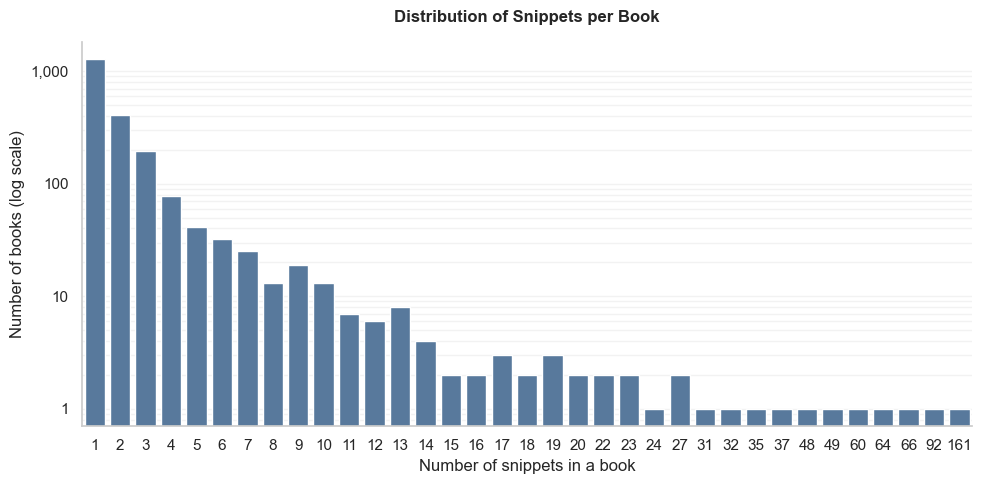

In [32]:
snippets_per_book = df_raw.groupby("Book_ID").size().rename("snippet_counts")
dist = snippets_per_book.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=dist.index, y=dist.values, color="#4C78A8", ax=ax)
ax.set_yscale("log")
ax.set_title("Distribution of Snippets per Book", pad=14, weight="bold")
ax.set_xlabel("Number of snippets in a book")
ax.set_ylabel("Number of books (log scale)")
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="y", which="both", alpha=0.25)
ax.grid(axis="x", visible=False)
sns.despine()
plt.tight_layout()

In [33]:
N = 10
opium_heavy_count = len(snippets_per_book[snippets_per_book > N])
opium_heavy_prop = 100 *  opium_heavy_count / len(snippets_per_book)
print(f"We observe {opium_heavy_count} opium heavy books (more than {N} snippets), ie {opium_heavy_prop:.1f} % of all opium mentionning books.")

df_raw.merge(right=snippets_per_book[snippets_per_book > N], on="Book_ID", how="inner").sort_values(["snippet_counts", "Book_ID"], ascending=False)

We observe 57 opium heavy books (more than 10 snippets), ie 2.6 % of all opium mentionning books.


,Unnamed: 0,Book_ID,Keyword,Snippet,Etext Number,Authors,LoCC,Published Year,Author Gender,Assigned_Gender,Character_Name,snippet_counts
383,1186,4508,nepenthe,"on the comical but for the fact that blank despair was written on the face of the mother. She evidently thought her last day had come, and still, in the convulsions of her pain...",4508,"Douglas, Norman",PR,1925,NaN,Unknown (Proper Noun),Anonymous,161
384,1189,4508,nepenthe,"Nepenthe, which he understood to be rather a small place. A few words of civility over the table d'hote had led to an exchange of cards--a continental custom which Mr. Heard al...",4508,"Douglas, Norman",PR,1925,NaN,Unknown (Proper Noun),Anonymous,161
385,1190,4508,nepenthe,"and more recently in Africa, where women are treated as the veriest beasts. He kept his ideals bright. He would tolerate no flippant allusions to the sex. Muhlen's talk had lef...",4508,"Douglas, Norman",PR,1925,NaN,Unknown (Proper Noun),Anonymous,161
386,1191,4508,nepenthe,"fond of joking. Well, he would humour him. ""You will see our bishop to-morrow,"" he pursued blandly. ""He comes over for the feast of the patron saint; you are lucky in witnessin...",4508,"Douglas, Norman",PR,1925,NaN,Unknown (Proper Noun),Anonymous,161
387,1192,4508,nepenthe,"this your first visit to Nepenthe?"" ""It is. I have heard much about the beauty of the place."" ""You will like it. The people are intelligent. There is good food and wine. Our lo...",4508,"Douglas, Norman",PR,1925,NaN,Unknown (Proper Noun),Anonymous,161
...,...,...,...,...,...,...,...,...,...,...,...,...
114,257,464,opium,The first roads were made under his auspices and by his persuasion. The old road between Hatiheu and Anaho was got under way from either side on the ground that it would be ple...,464,"Stevenson, Robert Louis",PR,1888,male,Unknown,Anonymous,11
115,258,464,opium,"a pillar: the armoury of these drowsy musketeers. At the far end, a little closed house of wood displayed some tinsel curtains, and proved, upon examination, to be a privy on t...",464,"Stevenson, Robert Louis",PR,1888,male,Male,Anonymous,11
116,259,464,opium,"he had earned it well. Again and again, at the command of Nakaeia, he had surrounded houses in the dead of night, cut down the mosquito bars and butchered families. Here was th...",464,"Stevenson, Robert Louis",PR,1888,male,Male,Corpse,11
117,260,464,opium,extreme consistency. Mr. Corpse was afraid of his brother: King Tebureimoa is afraid of the Old Men. Terror of the first nerved him for deeds of desperation; fear of the second...,464,"Stevenson, Robert Louis",PR,1888,male,Male,Kaeia,11


In [34]:
1398/5370

0.26033519553072626

In [35]:
# We manually inspect opium heavy books to exclude false positive, which might heavily skew Topic Modelling
false_opium_heavy_books = [4508, # fictional island called nepenthe
                           42299, # character named ANODYNE + published date = 1822
                           ]
df_raw = df_raw[~df_raw["Book_ID"].isin(false_opium_heavy_books)]

In [36]:
df_docs = prepare_documents(df_raw, text_col="Snippet")
df_docs = add_locc_group(df_docs, locc_col="LoCC")
df_docs = add_period_column(
    df_docs,
    year_col="Published Year",
    period_bins=PERIOD_BINS,
)

keyword_terms = set(df_docs["Keyword"].dropna().astype(str).str.lower()) | set(KEYWORDS)
STOP_WORDS = build_stop_words(df_docs["Snippet"], keywords=keyword_terms)

print(f"Prepared documents: {len(df_docs):,}")
print(f"Stop words: {len(STOP_WORDS):,}")
df_docs[["snippet_id", "Book_ID", "Keyword", "Assigned_Gender", "LoCC_group", "Period", "document"]].head()

Prepared documents: 5,195
Stop words: 370


,snippet_id,Book_ID,Keyword,Assigned_Gender,LoCC_group,Period,document
0,0,15,opium,Male,American Literature,1850-1880,they would rather not see whales than otherwise but all in vain those young platonists have a notion that their vision is imperfect they are short sighted what use then to stra...
1,1,15,paregoric,Male,American Literature,1850-1880,questionable for it is not customary for such venerable leviathans to be at all social nevertheless he stuck to their wake though indeed their back water must have retarded him...
2,2,15,laudanum,Male,American Literature,1850-1880,previous when the pequod spoke the town ho according to this account and what was subsequently learned it seemed that the scaramouch in question had gained a wonderful ascenden...
3,3,44,opium,Female,American Literature,1912-1930,and scared you nothing to cry about i m the same old goods only a little dented sit down on my coat there and keep me company i ve got to lay still a bit dr archie and mr kronb...
4,4,95,narcotic,Male,English Literature,1881-1911,that he asked why this i answered that i shall ill requite the very great honours ruritania has done me if i depart from it leaving one of those six alive neither with the help...


In [37]:
common_words = corpus_frequent_words(df_docs["Snippet"], min_document_share=0.25)
common_words.head(40)

Snippet
s         6854
opium     3526
said      3072
t         2673
man       2212
like      1960
time      1655
little    1649
did       1636
life      1388
know      1376
mr        1353
Name: count, dtype: int64

## 3) Topic modelling on all snippets

### A) Taking entire snippet

#### a) LDA with document = whole snippet

In [43]:
# ~ 4 min
lda_all = run_lda_topic_model(
    df_docs,
    stop_words=STOP_WORDS,
    candidate_topic_counts=ALL_LDA_TOPIC_COUNTS,
    group_label="all snippets",
    random_state=RANDOM_STATE,
    n_jobs=6,
    min_docs=20,
)

lda_all["scores"]

,n_topics,perplexity,log_likelihood
0,2,5702.640620,-3.289129e+06
1,4,5614.953683,-3.283236e+06
2,6,5720.963041,-3.290349e+06
3,8,5959.918986,-3.305911e+06
4,10,6150.964037,-3.317911e+06
5,12,6339.185007,-3.329373e+06
6,14,6470.809537,-3.337189e+06
7,16,6696.686109,-3.350238e+06
8,18,6890.904005,-3.361111e+06
9,20,7042.553422,-3.369389e+06


Selected topic count: 4


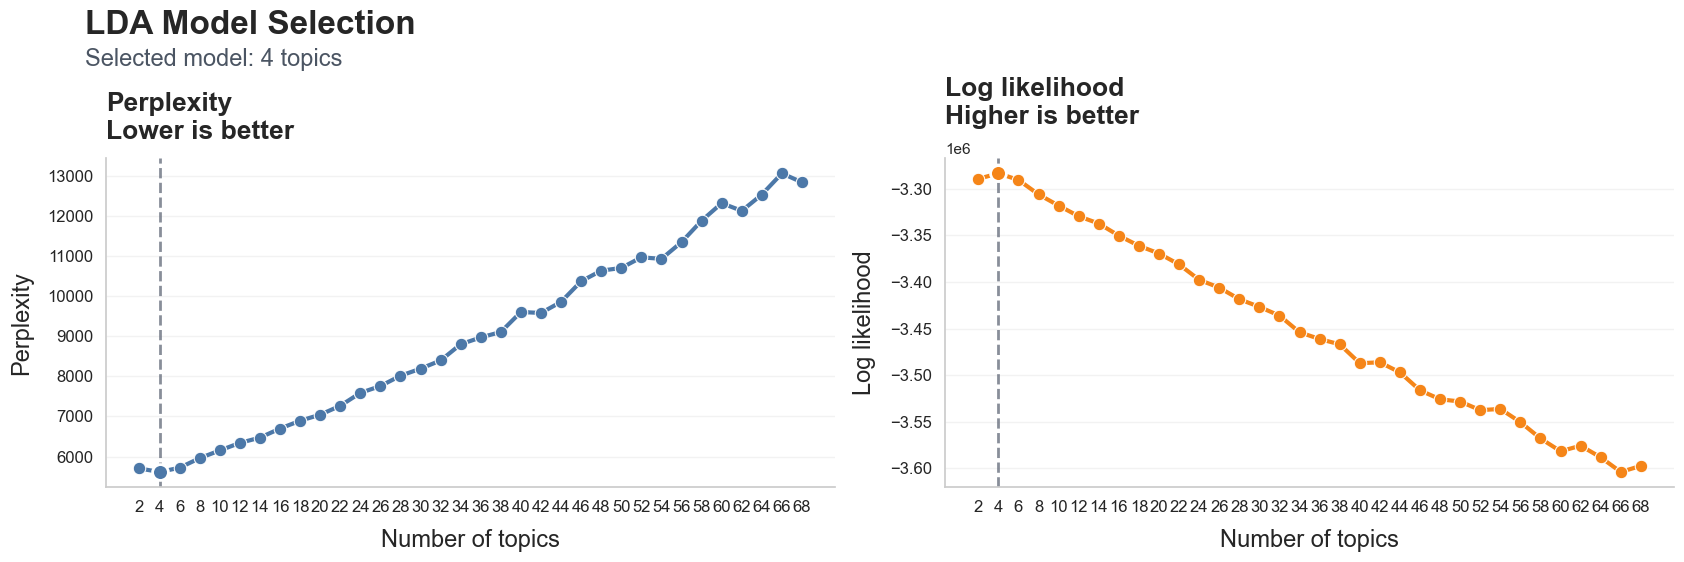

In [72]:
scores = lda_all["scores"].sort_values("n_topics")
selected_n_topics = lda_all["selected_n_topics"]

metrics = [
    ("perplexity", "Perplexity", "Lower is better", "#4C78A8"),
    ("log_likelihood", "Log likelihood", "Higher is better", "#F58518"),
]

fig, axes = plt.subplots(1, 2, figsize=(17, 7), sharex=True)

for ax, (metric, label, guidance, color) in zip(axes, metrics):
    sns.lineplot(
        data=scores,
        x="n_topics",
        y=metric,
        marker="o",
        markersize=9,
        linewidth=3,
        color=color,
        ax=ax,
    )

    selected_score = scores.loc[scores["n_topics"].eq(selected_n_topics), metric]
    ax.axvline(
        selected_n_topics,
        color="#6B7280",
        linestyle="--",
        linewidth=2,
        alpha=0.8,
    )

    if not selected_score.empty:
        ax.scatter(
            selected_n_topics,
            selected_score.iloc[0],
            s=130,
            color=color,
            edgecolor="white",
            linewidth=2,
            zorder=3,
        )

    ax.set_title(
        f"{label}\n{guidance}",
        loc="left",
        pad=14,
        fontsize=19,
        weight="bold",
    )
    ax.set_xlabel("Number of topics", fontsize=17, labelpad=10)
    ax.set_ylabel(label, fontsize=17, labelpad=10)
    ax.set_xticks(scores["n_topics"])
    ax.tick_params(axis="both", labelsize=12)
    ax.grid(axis="y", alpha=0.25)
    ax.grid(axis="x", visible=False)

fig.suptitle(
    "LDA Model Selection",
    x=0.055,
    y=0.8,
    ha="left",
    fontsize=24,
    weight="bold",
)
fig.text(
    0.055,
    0.72,
    f"Selected model: {selected_n_topics} topics",
    fontsize=17,
    color="#4B5563",
)

sns.despine()
plt.tight_layout(rect=(0, 0, 1, 0.8))

print(f"Selected topic count: {selected_n_topics}")

In [45]:
lda_all["summary"]

,model_group,dominant_topic,n_documents,mean_weight,n_books,top_terms
0,all snippets,0,2387,0.716482,1260,"room, night, old, good, eyes, face, sleep, day, hand, got, head, looked"
1,all snippets,1,1078,0.662565,696,"eyes, long, white, light, day, night, old, great, sin, away, air, heart"
3,all snippets,3,927,0.678539,512,"coleridge, great, years, work, quincey, english, new, london, good, day, world, book"
2,all snippets,2,803,0.673055,374,"death, case, drug, mind, doctor, dose, poison, knew, fact, taken, great, question"


In [ ]:
representative_lda_documents(lda_all["assignments"], topic_id=0, n=8)

,model_group,snippet_id,Book_ID,Keyword,topic_0,Snippet
3180,all snippets,3341,34813,opium,0.994517,"the yellow face reappeared. This time the door opened sufficiently for Trent to see a house-boy in a slop-shop suit and a black skull-cap. ""His Excellency sends greetings and b..."
427,all snippets,427,1182,opium,0.994414,"ancient Sam Tûk and at intervals of five minutes or more he would slowly nod his hairless head. The sliding door which concealed the inner room was partly open, and from the op..."
4745,all snippets,4920,65382,soporific,0.994264,meal at leisure. Donald’s happy laugh rang throughout the sylvan glade and was re-echoed mockingly from the cliffs. The camp-robbers emerged from their retreat looking rather c...
5180,all snippets,5355,73316,opium,0.994258,"axe and pistol in hand, had tumbled a half-dozen stalwart officers,--after them, Yee Wing. There were shrill, warning cries from the street. Shriller cries--the cries of panic-..."
4647,all snippets,4822,62347,opium,0.994255,"Japs, Malays, Lascars, with one or two white girls; and sleek, noiseless attendants swam from couch to couch. Away in the far corner sprawled a lank figure in brown shirting, i..."
4275,all snippets,4450,53289,opium,0.994163,"moment, then lifted it, not looking at him, and turned slowly back into her room. It was dark when he arrived in New York. The flaring streets of the city seemed horrible to hi..."
2247,all snippets,2408,17959,opium,0.994066,"She laughed softly, wickedly, and puffed cigarette smoke into my face. Thrusting her dagger into her waist-belt, and snatching up the brass tray, she swayed down the room, chan..."
2455,all snippets,2616,20429,opium,0.994023,"and Saul strode across a narrow yard, stooping to brush beneath the stout clothes-line hung with blankets, an innocent appearing wash, which however served as an effective barr..."


In [ ]:
if EXPORT_RESULTS:
    save_model_outputs(
        OUTPUT_DIR,
        "all_snippets_lda",
        topics=lda_all["topics"],
        summary=lda_all["summary"],
        assignments=lda_all["assignments"],
        scores=lda_all["scores"],
    )

In [ ]:
df_docs["Snippet"]

0       they would rather not see whales than otherwise. But all in vain; those young Platonists have a notion that their vision is imperfect; they are short-sighted; what use, then, t...
1       questionable; for it is not customary for such venerable leviathans to be at all social. Nevertheless, he stuck to their wake, though indeed their back water must have retarded...
2       previous when the Pequod spoke the Town-Ho. According to this account and what was subsequently learned, it seemed that the scaramouch in question had gained a wonderful ascend...
3       and scared you! Nothing to cry about. I’m the same old goods, only a little dented. Sit down on my coat there, and keep me company. I’ve got to lay still a bit.” Dr. Archie and...
4       that?” he asked. “Why this,” I answered. “That I shall ill requite the very great honours Ruritania has done me if I depart from it leaving one of those Six alive--neither with...
                                                            

In [ ]:
df_docs[df_docs.drop(columns="Authors").apply(lambda r : r.str.contains("Quincey").any(), axis=1)]

#### b) BERTopic with document = whole snippet

In [ ]:
# ~ 8 min
bertopic_all = run_bertopic_model(
    df_docs,
    stop_words=STOP_WORDS,
    embedding_model=HISTORICAL_EMBEDDING_MODEL,
    group_label="all snippets",
    min_docs=50,
    min_topic_size=50,
    nr_topics=20,
    verbose=False,
)

bertopic_all["topic_info"].head(25)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: emanjavacas/MacBERTh
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,model_group,Topic,Count,Name,Representation,Representative_Docs
0,all snippets,-1,2348,-1_night_day_old_eyes,"[night, day, old, eyes, room, long, good, great, face, sleep, mind, away]",[and leaves a corresponding mark well i heard her history she was married at fifteen ran away to be married and in spite of the fact that a railway accident nearly took her hus...
1,all snippets,0,317,0_death_case_administered_poisoning,"[death, case, administered, poisoning, dose, drug, evidence, witness, poison, doctor, died, question]",[has caused death has been known to cause death yes but that does not prove that it will always do so the habitu becomes wonderfully tolerant of it the records are replete with...
2,all snippets,1,144,1_love_heart_god_soul,"[love, heart, god, soul, sleep, day, night, away, old, eyes, long, rest]",[meant in croaking nevermore this i sat engaged in guessing but no syllable expressing to the fowl whose fiery eyes now burned into my bosom s core this and more i sat divining...
3,all snippets,2,943,2_good_got_room_doctor,"[good, got, room, doctor, old, want, night, let, look, right, asked, eyes]",[i have heard of this happening see if father isn t awake said mary raising her head from the pillow she had not heard what passed between her mother and mrs slade for the conv...
4,all snippets,3,211,3_room_eyes_door_lay,"[room, eyes, door, lay, face, small, hand, head, stood, light, pipe, floor]",[second strong door was partly hidden by a pile of empty packing cases and an untidy litter of straw and matting along the northern wall were more bunks and an open wooden stai...
5,all snippets,4,416,4_coleridge_quincey_great_english,"[coleridge, quincey, great, english, years, world, eater, wordsworth, dreams, poetry, work, literature]",[excessive but he produced a large amount of work then becoming loosely attached to the staff of blackwood s magazine he removed to edinburgh in this neighborhood he remained t...
6,all snippets,5,60,5_nicholas_nicholas carter_carter_chapter,"[nicholas, nicholas carter, carter, chapter, coleridge, charles, english, edited, thomas, william, essays, letters]",[by thomas hodgkin d c l charles auchester by e berger character by samuel smiles charles o malley by charles lever chesterfield s letters by lord chesterfield chevalier de mai...
7,all snippets,6,50,6_dana_sending_sahib_tchin,"[dana, sending, sahib, tchin, tchin len, len, englishman, good, low hee, white, hee, face]",[still going on but owing to some failure in the developing fluid they were not materialised the air was thick with letters for a few days afterwards unseen hands played gl ck ...
8,all snippets,7,300,7_old_new_great_long,"[old, new, great, long, chinese, white, street, day, place, bradys, days, room]",[two would come up with a song from the sea moti guj all black and shining waving a torn tree branch twelve feet long in his trunk and deesa knotting up his own long wet hair k...
9,all snippets,8,406,8_felt_day_knew_away,"[felt, day, knew, away, room, eyes, mind, long, heart, night, father, hand]",[softly with one of the old sweet thoughtful smiles shining in his eyes then mr berners who would have liked to linger longer near this sympathizing friend who was working so z...


In [ ]:
bertopic_all["summary"]

,model_group,bertopic_topic,n_documents,mean_probability,n_books,top_terms
0,all snippets,-1,2348,0.158186,1283,"night, day, old, eyes, room, long, good, great, face, sleep, mind, away"
3,all snippets,2,943,0.453599,585,"good, got, room, doctor, old, want, night, let, look, right, asked, eyes"
5,all snippets,4,416,0.433284,231,"coleridge, quincey, great, english, years, world, eater, wordsworth, dreams, poetry, work, literature"
9,all snippets,8,406,0.623592,299,"felt, day, knew, away, room, eyes, mind, long, heart, night, father, hand"
1,all snippets,0,317,0.402495,100,"death, case, administered, poisoning, dose, drug, evidence, witness, poison, doctor, died, question"
8,all snippets,7,300,0.497191,222,"old, new, great, long, chinese, white, street, day, place, bradys, days, room"
4,all snippets,3,211,0.554443,134,"room, eyes, door, lay, face, small, hand, head, stood, light, pipe, floor"
2,all snippets,1,144,0.641024,116,"love, heart, god, soul, sleep, day, night, away, old, eyes, long, rest"
6,all snippets,5,60,0.979269,42,"nicholas, nicholas carter, carter, chapter, coleridge, charles, english, edited, thomas, william, essays, letters"
7,all snippets,6,50,1.000000,39,"dana, sending, sahib, tchin, tchin len, len, englishman, good, low hee, white, hee, face"


In [ ]:
representative_bertopic_documents(bertopic_all["assignments"], topic_id=0, n=8)

,model_group,snippet_id,Book_ID,Keyword,bertopic_topic_probability,Snippet
2973,all snippets,3134,32985,morphine,1.0,"death."" ""But you are certain that she had Bright's disease?"" ""Yes, sir."" ""That is all."" Professor Orton then took the stand for the prosecution. Under the questioning of Mr. Mu..."
1823,all snippets,1984,12187,morphine,1.0,suicide. But the patient's condition seems equally to exclude the idea of morphinomania. Your opium-eater does not reduce himself to a state of coma. He usually keeps well with...
991,all snippets,1152,4946,narcotic,1.0,"blood; the stomach was somewhat congested, and contained a little partially digested food; the intestines here and there were congested, and throughout the body the blood was d..."
2959,all snippets,3120,32985,opium,1.0,"far to corroborate this presumption."" ""Then if the chemical analysis shows the actual presence of opium, would you say that this patient died of opium poisoning?"" ""I would!"" ""D..."
2958,all snippets,3119,32985,opium,1.0,"died of coma!"" was the reply. ""Can you state whether this coma had been produced by a poisonous dose of morphine?"" ""I should say that it was very probable that opium in some fo..."
2957,all snippets,3118,32985,opium,1.0,"weight with them, not alone as to his own evidence, but by strengthening the chemical report, since he had made it apparently assured that if poison had been found, it had not ..."
2956,all snippets,3117,32985,opium,1.0,"opium."" ""Now then, Doctor, admitting that the contracted pupils are a sign of morphine, how did you determine, in that darkened room, that there was a contraction of the pupils..."
2955,all snippets,3116,32985,opium,1.0,"of these symptoms in Miss Sloane?"" ""Yes. Practically all of them."" ""And would these same symptoms occur in any other form of death, except from morphine poisoning?"" ""They would..."


In [ ]:
if EXPORT_RESULTS:
    save_model_outputs(
        OUTPUT_DIR,
        "all_snippets_bertopic",
        topics=bertopic_all["topics"],
        summary=bertopic_all["summary"],
        assignments=bertopic_all["assignments"],
        topic_info=bertopic_all["topic_info"],
    )

### B) Taking sentence by sentence

#### a) Splitting the data by sentence

In [51]:
df_sentences = split_snippets_into_sentences(df_docs, text_col="Snippet", min_words=6)
df_sentences = prepare_documents(df_sentences, text_col="Snippet", id_col="sentence_id")

print(f"Sentence documents: {len(df_sentences):,}")
df_sentences[["sentence_id", "snippet_id", "Book_ID", "Keyword", "Snippet", "document"]].head()

Sentence documents: 48,415


,sentence_id,snippet_id,Book_ID,Keyword,Snippet,document
0,0_0,0,15,opium,they would rather not see whales than otherwise.,they would rather not see whales than otherwise
1,0_1,0,15,opium,"But all in vain; those young Platonists have a notion that their vision is imperfect; they are short-sighted; what use, then, to strain the visual nerve?",but all in vain those young platonists have a notion that their vision is imperfect they are short sighted what use then to strain the visual nerve
2,0_2,0,15,opium,They have left their opera-glasses at home.,they have left their opera glasses at home
3,0_3,0,15,opium,"“Why, thou monkey,” said a harpooneer to one of these lads, “we’ve been cruising now hard upon three years, and thou hast not raised a whale yet.",why thou monkey said a harpooneer to one of these lads we ve been cruising now hard upon three years and thou hast not raised a whale yet
4,0_4,0,15,opium,Whales are scarce as hen’s teeth whenever thou art up here.” Perhaps they were; or perhaps there might have been shoals of them in the far horizon; but lulled into such an opiu...,whales are scarce as hen s teeth whenever thou art up here perhaps they were or perhaps there might have been shoals of them in the far horizon but lulled into such an opium li...


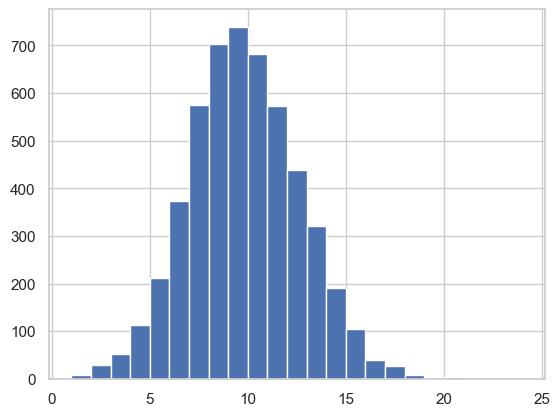

In [52]:
sentences_nbs = df_sentences.groupby("snippet_id").size()
min_nb = sentences_nbs.min()
max_nb = sentences_nbs.max()
plt.hist(sentences_nbs, bins=range(min_nb, max_nb + 1))
plt.show()

#### b) LDA with document = one sentence

In [ ]:
lda_sentences = run_lda_topic_model(
    df_sentences,
    stop_words=STOP_WORDS,
    candidate_topic_counts=ALL_LDA_TOPIC_COUNTS,
    group_label="sentence-level snippets",
    id_col="sentence_id",
    random_state=RANDOM_STATE,
    n_jobs=6,
    min_docs=50,
    min_df=5,
)

lda_sentences["scores"]

,n_topics,perplexity,log_likelihood
0,2,6002.716550,-3.217683e+06
1,3,6337.664220,-3.237765e+06
2,4,6657.192413,-3.255957e+06
3,5,6940.180175,-3.271354e+06
4,6,7117.992889,-3.280710e+06
5,7,7287.939348,-3.289437e+06
6,8,7449.353884,-3.297539e+06
7,9,7568.004020,-3.303384e+06
8,10,7671.901880,-3.308427e+06
9,11,7789.344677,-3.314045e+06


In [ ]:
lda_sentences["summary"]

,model_group,dominant_topic,n_documents,mean_weight,n_books,top_terms
1,sentence-level snippets,1,25400,0.779186,2124,"day, good, mind, great, world, years, new, work, old, love, people, drug"
0,sentence-level snippets,0,23015,0.767656,2022,"room, eyes, face, night, hand, house, head, old, looked, away, door, long"


In [ ]:
#representative_lda_documents(lda_sentences["assignments"], topic_id=0, n=10)

In [ ]:
if EXPORT_RESULTS:
    save_model_outputs(
        OUTPUT_DIR,
        "sentence_level_lda",
        topics=lda_sentences["topics"],
        summary=lda_sentences["summary"],
        assignments=lda_sentences["assignments"],
        scores=lda_sentences["scores"],
    )

#### c) BERTopic with document = one sentence

The first sentence-level BERTopic run on all split sentences produced some useful topics, but also very large generic clusters because many sentences in each snippet are only loose narrative context. The tuned run below keeps the sentence containing an opium-related target term plus one neighboring sentence on each side, then tests several HDBSCAN cluster-size settings without reducing topics afterward.

In [53]:
df_sentence_context = add_keyword_context_flags(
    df_sentences,
    keywords=keyword_terms,
    text_col="Snippet",
    window=SENTENCE_CONTEXT_WINDOW,
)
df_sentence_context = df_sentence_context.loc[df_sentence_context["near_target_term"]].copy().reset_index(drop=True)

print(f"All sentence documents: {len(df_sentences):,}")
print(f"Keyword-context sentence documents: {len(df_sentence_context):,}")
print(f"Direct keyword sentence documents: {df_sentence_context['contains_target_term'].sum():,}")

df_sentence_context[["sentence_id", "snippet_id", "Keyword", "contains_target_term", "Snippet"]].head()

All sentence documents: 48,415
Keyword-context sentence documents: 17,152
Direct keyword sentence documents: 6,255


,sentence_id,snippet_id,Keyword,contains_target_term,Snippet
0,0_3,0,opium,False,"“Why, thou monkey,” said a harpooneer to one of these lads, “we’ve been cruising now hard upon three years, and thou hast not raised a whale yet."
1,0_4,0,opium,True,Whales are scarce as hen’s teeth whenever thou art up here.” Perhaps they were; or perhaps there might have been shoals of them in the far horizon; but lulled into such an opiu...
2,0_5,0,opium,False,"In this enchanted mood, thy spirit ebbs away to whence it came; becomes diffused through time and"
3,1_2,1,paregoric,False,"His spout was short, slow, and laborious; coming forth with a choking sort of gush, and spending itself in torn shreds, followed by strange subterranean commotions in him, whic..."
4,1_3,1,paregoric,True,"“Who’s got some paregoric ?” said Stubb, “he has the stomach-ache, I’m afraid."


In [54]:
SENTENCE_EXTRA_STOP_WORDS = {
    "old", "good", "great", "little", "long", "look", "looked", "looking", "saw",
    "eyes", "face", "hand", "head", "hands", "room", "door", "house", "place",
    "day", "came", "went", "got", "asked", "answered", "replied", "told", "said",
    "says", "sir", "mr", "mrs", "miss", "thing", "things", "people", "man", "men",
    "woman", "women", "girl", "boy", "father", "mother", "friend", "dear", "poor",
}

SENTENCE_CONTEXT_STOP_WORDS = sorted(
    set(build_stop_words(df_sentence_context["Snippet"], keywords=keyword_terms, min_document_share=0.12))
    #| SENTENCE_EXTRA_STOP_WORDS
)

print(f"Sentence-context stop words: {len(SENTENCE_CONTEXT_STOP_WORDS):,}")

Sentence-context stop words: 367


In [55]:
if RUN_SENTENCE_BERTOPIC_TUNING:
    if SENTENCE_CONTEXT_EMBEDDINGS.exists():
        sentence_context_embeddings = np.load(SENTENCE_CONTEXT_EMBEDDINGS)
        if len(sentence_context_embeddings) != len(df_sentence_context):
            sentence_context_embeddings = None
    else:
        sentence_context_embeddings = None

    if sentence_context_embeddings is None:
        sentence_encoder = SentenceTransformer(SENTENCE_LEVEL_EMBEDDING_MODEL)
        sentence_context_embeddings = sentence_encoder.encode(
            df_sentence_context["document"].tolist(),
            batch_size=64,
            show_progress_bar=True,
            normalize_embeddings=True,
        )
        np.save(SENTENCE_CONTEXT_EMBEDDINGS, sentence_context_embeddings)
else:
    sentence_context_embeddings = None

In [56]:
# ~ 2 min
tuned_sentence_results = {}
tuned_sentence_diagnostics = []

if RUN_SENTENCE_BERTOPIC_TUNING:
    for config in TUNED_SENTENCE_BERTOPIC_CONFIGS:
        print(f"Fitting {config['name']}...")
        umap_model = UMAP(
            n_neighbors=config["n_neighbors"],
            n_components=5,
            min_dist=0.0,
            metric="cosine",
            random_state=RANDOM_STATE,
        )
        hdbscan_model = HDBSCAN(
            min_cluster_size=config["min_cluster_size"],
            min_samples=config["min_samples"],
            metric="euclidean",
            cluster_selection_method="leaf", # "most fine grained and homogeneous clusters"
            prediction_data=False,
        )

        result = run_bertopic_model(
            df_sentence_context,
            stop_words=SENTENCE_CONTEXT_STOP_WORDS,
            embedding_model=SENTENCE_LEVEL_EMBEDDING_MODEL,
            embeddings=sentence_context_embeddings,
            group_label=config["name"],
            text_col="document",
            id_col="sentence_id",
            min_docs=50,
            min_topic_size=config["min_cluster_size"],
            nr_topics=None, # None gave 60 good topics, slighty duplicated using context_leaf_mcs60_ms1_nn10
            calculate_probabilities=False,
            vectorizer_min_df=1,
            vectorizer_max_df=0.90,
            vectorizer_ngram_range=(1, 3),
            verbose=False,
            bertopic_kwargs={
                "umap_model": umap_model,
                "hdbscan_model": hdbscan_model,
                "ctfidf_model": ClassTfidfTransformer(reduce_frequent_words=True),
            },
        )
        tuned_sentence_results[config["name"]] = result

        diagnostics = bertopic_size_diagnostics(
            result["summary"],
            total_documents=len(df_sentence_context),
            rich_topic_min_size=30,
            rich_topic_max_size=400,
        )
        diagnostics.update(config)
        tuned_sentence_diagnostics.append(diagnostics)

        if EXPORT_RESULTS:
            save_model_outputs(
                OUTPUT_DIR,
                f"tuned_sentence_bertopic_{config['name']}",
                topics=result["topics"],
                summary=result["summary"],
                assignments=result["assignments"],
                topic_info=result["topic_info"],
            )

tuned_sentence_diagnostics = pd.DataFrame(tuned_sentence_diagnostics)
if not tuned_sentence_diagnostics.empty:
    tuned_sentence_diagnostics = tuned_sentence_diagnostics.sort_values(
        ["largest_topic_share", "outlier_share", "n_rich_sized_topics"],
        ascending=[True, True, False],
    )
    if EXPORT_RESULTS:
        tuned_sentence_diagnostics.to_csv(OUTPUT_DIR / "tuned_sentence_bertopic_diagnostics.csv", index=False)

tuned_sentence_diagnostics

""


In [57]:
if RUN_SENTENCE_BERTOPIC_TUNING:
    eligible_tuned_models = tuned_sentence_diagnostics.loc[
        (tuned_sentence_diagnostics["largest_topic_share"] <= 0.25)
        & (tuned_sentence_diagnostics["n_topics"] >= 8)
    ].copy()
    if eligible_tuned_models.empty:
        selected_sentence_config = tuned_sentence_diagnostics.iloc[0]["name"]
    else:
        selected_sentence_config = (
            eligible_tuned_models
            .sort_values(["outlier_share", "n_rich_sized_topics", "largest_topic_share"], ascending=[True, False, True])
            .iloc[0]["name"]
        )
    bertopic_sentences = tuned_sentence_results[selected_sentence_config]
else:
    selected_sentence_config = "sentence_context_bertopic_tuned_final"
    bertopic_sentences = {
        "topics": pd.read_csv(OUTPUT_DIR / "final_model/sentence_context_bertopic_tuned_final_topics_terms.csv"),
        "summary": pd.read_csv(OUTPUT_DIR / "final_model/sentence_context_bertopic_tuned_final_topic_summary.csv"),
        "assignments": pd.read_csv(OUTPUT_DIR / "final_model/sentence_context_bertopic_tuned_final_document_topics.csv"),
        "topic_info": pd.read_csv(OUTPUT_DIR / "final_model/sentence_context_bertopic_tuned_final_topic_info.csv"),
    }

print(f"Selected tuned sentence BERTopic model: {selected_sentence_config}")
bertopic_sentences["topic_info"]

Selected tuned sentence BERTopic model: sentence_context_bertopic_tuned_final


,model_group,Topic,Count,Name,Representation,Representative_Docs
0,context_leaf_mcs60_ms1_nn10,-1,8749,-1_eyes_room_night_old,"['eyes', 'room', 'night', 'old', 'face', 'life', 'long', 'good', 'away', 'woman', 'hand', 'house']",['she hung the biscuit in a pail down the well and set away the butter in the bread box put sugar instead of salt into the bread sponge she was setting and finally before she s...
1,context_leaf_mcs60_ms1_nn10,0,420,0_felt_evil_life_energy,"['felt', 'evil', 'life', 'energy', 'misery', 'mind', 'conscience', 'failure', 'power', 'seldom', 'knew', 'constantly']",['if thousands of people had cursed him if tens of thousands of workmen had sweated for him if hundreds of thousands of cattle had perished for him if gambling hells and drinki...
2,context_leaf_mcs60_ms1_nn10,1,408,1_habit_ali_eater_eating,"['habit', 'ali', 'eater', 'eating', 'smoker', 'neuralgia', 'money', 'knew', 'excusable', 'large quantities', 'smoking', 'dupe']",['upon these entrancing and well discussed plans however the shadow of the grasping and commonplace ah ping has fallen like the inopportune opium pipe from the mouth of a perso...
3,context_leaf_mcs60_ms1_nn10,2,352,2_doctor_physician_fever_medical,"['doctor', 'physician', 'fever', 'medical', 'patient', 'surgeon', 'ill', 'disease', 'symptoms', 'morrhage', 'severe', 'wounds']",['but doctor when you see christian science enrolling the names of the most brilliant minds when you see the loveliest women forsaking a life of ease and pleasure and becoming ...
4,context_leaf_mcs60_ms1_nn10,3,315,3_rita_husband_insane_leroux,"['rita', 'husband', 'insane', 'leroux', 'smuggling', 'thousand pounds', 'eater', 'poppies', 'smoked', 'pipe', 'wild', 'denise ryland']",['i am sure she must have seen those awful prisons of his out of which the opium eater got his nightmare vision described by another as cemeteries of departed greatness where m...
5,context_leaf_mcs60_ms1_nn10,4,297,4_sleep_nightmare_dream_dreams,"['sleep', 'nightmare', 'dream', 'dreams', 'mac', 'asleep', 'tired', 'vividly', 'sleep nightmare', 'possibly accident', 'awake', 'night']",['my friends think my life was a perfect gift but a burning cinder was placed in my breast and time has blown it into flame in the soporific scent of the lilies and the stocks ...
6,context_leaf_mcs60_ms1_nn10,5,259,5_chair_eyes_bed_breathing,"['chair', 'eyes', 'bed', 'breathing', 'face', 'robe', 'turned', 'foot', 'hat', 'head', 'gaston', 'coat']",['with a wonderful celerity for him his upper garment which was of pale blue silk and buttoned with unbecoming tightness over his unwieldy figure was turned inside out and a pl...
7,context_leaf_mcs60_ms1_nn10,6,243,6_stimulant_powerful_effects_drug,"['stimulant', 'powerful', 'effects', 'drug', 'effect', 'began', 'fell fast', 'practise', 'influence', 'sleep', 'administered', 'lungs']",['only the present remained the idle thoughtful half narcotic present with a mazy charm no man could explain since so far as any bodily good was concerned there was less comfor...
8,context_leaf_mcs60_ms1_nn10,7,239,7_trees_atmosphere_forest_sun,"['trees', 'atmosphere', 'forest', 'sun', 'hills', 'bird', 'roof', 'air', 'breeze', 'sky', 'flowers', 'summer']",['field and forest call there is a field that leans upon two hills foamed o er with flowers and twinkling with clear rills that in its girdle of wild acres bears the anodyne of...
9,context_leaf_mcs60_ms1_nn10,8,238,8_pain_sorrow_healing_eve,"['pain', 'sorrow', 'healing', 'eve', 'friendship', 'labor', 'nobly', 'love', 'despair', 'lulled', 'prove', 'suffering']",['it is a tonic for those who need strength and an anodyne for those who require soothing and a febrifuge for those who want their blood cooled a filling up for minds pumped dr...


In [18]:
df_sentences[df_sentences["Book_ID"] == 55276]

,Unnamed: 0,Book_ID,Keyword,Snippet,Etext Number,Authors,LoCC,Published Year,Author Gender,Assigned_Gender,Character_Name,snippet_id,document,LoCC_group,Period,sentence_id,sentence_number
40305,5680,55276,opium,"“When I came here, the first time, the first day, and saw you sitting in her chair, at her table, in her attitude, as I said, it was a reincarnation.” He got up from the music ...",55276,"Frankau, Julia",PR,1926,NaN,Male,Anonymous,4529,when i came here the first time the first day and saw you sitting in her chair at her table in her attitude as i said it was a reincarnation he got up from the music stool and ...,English Literature,1912-1930,4529_0,0
40306,5680,55276,opium,"He said, without preliminary or excuse, “You are taking opium in some form or other.” “I am taking my medicine.” “I am not blaming you.",55276,"Frankau, Julia",PR,1926,NaN,Male,Anonymous,4529,he said without preliminary or excuse you are taking opium in some form or other i am taking my medicine i am not blaming you,English Literature,1912-1930,4529_1,1
40307,5680,55276,opium,"You’ve read De Quincey, haven’t you?",55276,"Frankau, Julia",PR,1926,NaN,Male,Anonymous,4529,you ve read de quincey haven t you,English Literature,1912-1930,4529_2,2
40308,5680,55276,opium,"You know his theory?” “Some of it.” “Never mind; perhaps you’ve missed it, better if you have.",55276,"Frankau, Julia",PR,1926,NaN,Male,Anonymous,4529,you know his theory some of it never mind perhaps you ve missed it better if you have,English Literature,1912-1930,4529_3,3
40309,5680,55276,opium,In those days it was often thought that opium cured consumption.” “Then it is consumption?” “What does it matter what we call it?,55276,"Frankau, Julia",PR,1926,NaN,Male,Anonymous,4529,in those days it was often thought that opium cured consumption then it is consumption what does it matter what we call it,English Literature,1912-1930,4529_4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40517,5704,55276,codein,No extra codein for me any more.,55276,"Frankau, Julia",PR,1926,NaN,Female,Margaret,4547,no extra codein for me any more,English Literature,1912-1930,4547_7,7
40518,5704,55276,codein,"I no longer wanted to dream, only to face what was before me with courage.",55276,"Frankau, Julia",PR,1926,NaN,Female,Margaret,4547,i no longer wanted to dream only to face what was before me with courage,English Literature,1912-1930,4547_8,8
40519,5704,55276,codein,"My writing-block was by my side and pencils, one of Ella’s last gifts, and I drew them toward me.",55276,"Frankau, Julia",PR,1926,NaN,Female,Margaret,4547,my writing block was by my side and pencils one of ella s last gifts and i drew them toward me,English Literature,1912-1930,4547_9,9
40520,5704,55276,codein,"I had to break to her that if she would be lonely in the world without me, then it was time for her to prepare for loneliness.",55276,"Frankau, Julia",PR,1926,NaN,Female,Margaret,4547,i had to break to her that if she would be lonely in the world without me then it was time for her to prepare for loneliness,English Literature,1912-1930,4547_10,10


In [19]:
mask = ["fear" in doc.split(' ') for doc in df_sentences["document"]]
df_sentences[mask]

,Unnamed: 0,Book_ID,Keyword,Snippet,Etext Number,Authors,LoCC,Published Year,Author Gender,Assigned_Gender,Character_Name,snippet_id,document,LoCC_group,Period,sentence_id,sentence_number
468,63,155,opium,"Otherwise, I should be inclined to fear that he will be totally unfit for the experiment when the time comes to try it.",155,"Collins, Wilkie",PR,1868,female,Female,Anonymous,49,otherwise i should be inclined to fear that he will be totally unfit for the experiment when the time comes to try it,English Literature,1850-1880,49_0,0
930,114,155,laudanum,In the fear of an accident happening he followed you softly to see what you would do.,155,"Collins, Wilkie",PR,1868,female,Male,Verinder,88,in the fear of an accident happening he followed you softly to see what you would do,English Literature,1850-1880,88_6,6
1132,133,173,opium,The fierce resentment born of dreadful wrongs was consuming her now; but fear of Fu-Manchu held her yet.,173,"Rohmer, Sax",PR,1913,male,Unknown,Anonymous,107,the fierce resentment born of dreadful wrongs was consuming her now but fear of fu manchu held her yet,English Literature,1912-1930,107_11,11
1856,214,345,narcotic,"“Do not stir,” he said, “but I fear that with growing strength she may wake; and that would make danger, oh, so much danger.",345,"Stoker, Bram",PR,1897,male,Male,Lucy,179,do not stir he said but i fear that with growing strength she may wake and that would make danger oh so much danger,English Literature,1881-1911,179_1,1
2171,258,464,opium,"We were to grow better acquainted, and first and last I had the same impression; he seemed always drowsy, yet always to hearken and start; and, whether from remorse or fear, th...",464,"Stevenson, Robert Louis",PR,1888,male,Male,Anonymous,211,we were to grow better acquainted and first and last i had the same impression he seemed always drowsy yet always to hearken and start and whether from remorse or fear there is...,English Literature,1881-1911,211_4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47322,6529,72609,soporific,"The church and Sunday School at Elmer’s village, Paris, Kansas, a settlement of nine hundred evangelical Germans and Vermonters, had nurtured in him a fear of religious machine...",72609,"Lewis, Sinclair",PS,1926,male,Male,Missionary Suppers,5257,the church and sunday school at elmer s village paris kansas a settlement of nine hundred evangelical germans and vermonters had nurtured in him a fear of religious machinery w...,American Literature,1912-1930,5257_1,1
47717,6578,72849,opium,"First, the bartender scowled at him and asked what he would take, and when he refused to take anything, having a just fear that any liquor sold in such a place would be only le...",72849,"Lynde, Francis",PS,1916,male,Male,Forsyth,5298,first the bartender scowled at him and asked what he would take and when he refused to take anything having a just fear that any liquor sold in such a place would be only less ...,American Literature,1912-1930,5298_7,7
48133,6628,73254,opium,One thing was certain: there was not a trace of fear in his manner though it seemed to me he was rather curious as to who Bartley might be.,73254,"Dutton, Charles J. (Charles Judson)",PS,1926,NaN,Male,Chinaman,5343,one thing was certain there was not a trace of fear in his manner though it seemed to me he was rather curious as to who bartley might be,American Literature,1912-1930,5343_1,1
48307,6645,73409,anodyne,He had no longer to fear that awful suspense which had the power to overthrow the firmest intelligence.,73409,"Snaith, J. C. (John Collis)",PR,1923,male,Male,Anonymous,5358,he had no longer to fear that awful suspense which had the power to overthrow the firmest intelligence,English Literature,1912-1930,5358_12,12


In [20]:
if EXPORT_RESULTS:
    save_model_outputs(
        OUTPUT_DIR,
        "final_model/sentence_context_bertopic_tuned_final",
        topics=bertopic_sentences["topics"],
        summary=bertopic_sentences["summary"],
        assignments=bertopic_sentences["assignments"],
        topic_info=bertopic_sentences["topic_info"],
    )

## 4) Topic distribution by Gender

The final sentence-level BERTopic model is now treated as a shared topic space. The cells below do not fit new models; they only compare how the final topics are distributed across metadata groups. Unless stated otherwise, topic `-1` is excluded from the percentage denominators because it is the BERTopic outlier bucket.

For each metadata split, the notebook now reports a global chi-square test of independence, pairwise group comparisons, and per-topic one-vs-rest chi-square tests. The per-topic p-values are Benjamini-Hochberg adjusted, and heatmap rows are ordered from the strongest to weakest adjusted significance.

In [58]:
FINAL_TOPIC_ASSIGNMENTS_PATH = OUTPUT_DIR / "final_model/sentence_context_bertopic_tuned_final_document_topics.csv"
FINAL_TOPIC_TERMS_PATH = OUTPUT_DIR / "final_model/sentence_context_bertopic_tuned_final_topics_terms.csv"

if "bertopic_sentences" in globals() and isinstance(bertopic_sentences, dict):
    df_final_topics = bertopic_sentences["assignments"].copy()
    final_topic_terms = bertopic_sentences["topics"].copy()
else:
    df_final_topics = pd.read_csv(FINAL_TOPIC_ASSIGNMENTS_PATH)
    final_topic_terms = pd.read_csv(FINAL_TOPIC_TERMS_PATH)

df_final_topics = add_topic_labels(
    df_final_topics,
    final_topic_terms,
    assignment_topic_col="bertopic_topic",
    topic_col="topic",
    terms_col="top_terms",
    max_terms=5,
)

df_final_topics["Author_Gender_Group"] = (
    df_final_topics["Author Gender"]
    .fillna("Unknown")
    .replace("", "Unknown")
    .astype(str)
    .str.strip()
    .str.title()
)
df_final_topics["Assigned_Gender_Group"] = (
    df_final_topics["Assigned_Gender"]
    .fillna("Unknown")
    .replace("", "Unknown")
    .astype(str)
    .str.strip()
)
df_final_topics["LoCC_Display"] = (
    df_final_topics["LoCC"]
    .fillna("Unknown")
    .replace("", "Unknown")
    .astype(str)
    .str.strip()
)
df_final_topics = add_period_column(
    df_final_topics,
    year_col="Published Year",
    period_bins=PERIOD_BINS,
)
df_final_topics["Period"] = df_final_topics["Period"].astype("string")
SELECTED_TOPIC_LABELS = {
    1: "Opium as a smoking habit",
    6: "The power of the stimulant",
    8: "Pain and sorrow",
    9: "An illegal marchandise",
    13: "Through olfaction",
    15: "De Quincey's book as a reference",
    16: "Refering to Coleridge himself",
    19: "Poison",
}
SELECTED_TOPIC_IDS = list(SELECTED_TOPIC_LABELS)

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.15)
plt.rcParams.update({
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "legend.title_fontsize": 12,
})

df_final_topics["bertopic_topic"] = df_final_topics["bertopic_topic"].astype(int)
df_final_topics = df_final_topics.loc[
    df_final_topics["bertopic_topic"].isin(SELECTED_TOPIC_IDS)
].copy()
df_final_topics["topic_label"] = df_final_topics["bertopic_topic"].map(SELECTED_TOPIC_LABELS)

outlier_mask = df_final_topics["bertopic_topic"].astype(int).eq(-1)
topic_assignment_sanity = pd.DataFrame({
    "metric": [
        "n_sentence_contexts",
        "n_snippets",
        "n_books",
        "outlier_sentence_contexts",
        "outlier_share",
    ],
    "value": [
        df_final_topics["sentence_id"].nunique(),
        df_final_topics["snippet_id"].nunique(),
        df_final_topics["Book_ID"].nunique(),
        int(outlier_mask.sum()),
        outlier_mask.mean(),
    ],
})
topic_assignment_sanity

,metric,value
0,n_sentence_contexts,1771.0
1,n_snippets,1425.0
2,n_books,818.0
3,outlier_sentence_contexts,0.0
4,outlier_share,0.0


In [59]:
def benjamini_hochberg(p_values):
    p_values = pd.Series(p_values, dtype="float64")
    adjusted = pd.Series(np.nan, index=p_values.index, dtype="float64")
    valid = p_values.dropna().sort_values(ascending=True)
    n_tests = len(valid)
    if n_tests == 0:
        return adjusted

    ranked = valid * n_tests / np.arange(1, n_tests + 1)
    adjusted_valid = ranked.iloc[::-1].cummin().iloc[::-1].clip(upper=1)
    adjusted.loc[adjusted_valid.index] = adjusted_valid
    return adjusted


def _as_group_cols(group_cols):
    return [group_cols] if isinstance(group_cols, str) else list(group_cols)


def _add_group_label(df, group_cols, label_col="group_label"):
    group_cols = _as_group_cols(group_cols)
    labelled = df.copy()
    if len(group_cols) == 1:
        labelled[label_col] = labelled[group_cols[0]].astype(str)
    else:
        labelled[label_col] = labelled[group_cols].astype(str).agg(" | ".join, axis=1)
    return labelled


def topic_group_contingency(
    df,
    group_cols,
    topic_col="bertopic_topic",
    label_col="topic_label",
    unit_col="sentence_id",
    include_outlier=False,
    min_group_total=1,
):
    group_cols = _as_group_cols(group_cols)
    analysis_df = df.dropna(subset=group_cols + [topic_col, label_col, unit_col]).copy()
    analysis_df[topic_col] = analysis_df[topic_col].astype(int)
    if not include_outlier:
        analysis_df = analysis_df.loc[analysis_df[topic_col] != -1]

    topic_lookup = (
        analysis_df[[topic_col, label_col]]
        .drop_duplicates(subset=[topic_col])
        .set_index(topic_col)[label_col]
    )
    counts = (
        analysis_df.groupby(group_cols + [topic_col])[unit_col]
        .nunique()
        .rename("n_documents")
        .reset_index()
    )
    labelled = _add_group_label(counts, group_cols)
    contingency = labelled.pivot_table(
        index="group_label",
        columns=topic_col,
        values="n_documents",
        fill_value=0,
        aggfunc="sum",
    ).astype(int)
    group_totals = contingency.sum(axis=1)
    contingency = contingency.loc[group_totals >= min_group_total]
    contingency = contingency.loc[:, contingency.sum(axis=0) > 0]
    return contingency, topic_lookup


def cramers_v(chi2, n_observations, shape):
    if n_observations == 0:
        return np.nan
    min_dim = min(shape[0] - 1, shape[1] - 1)
    if min_dim <= 0:
        return np.nan
    return np.sqrt((chi2 / n_observations) / min_dim)


def chi_square_topic_distribution_tests(
    df,
    group_cols,
    topic_col="bertopic_topic",
    label_col="topic_label",
    unit_col="sentence_id",
    include_outlier=False,
    min_group_total=1,
):
    contingency, topic_lookup = topic_group_contingency(
        df,
        group_cols,
        topic_col=topic_col,
        label_col=label_col,
        unit_col=unit_col,
        include_outlier=include_outlier,
        min_group_total=min_group_total,
    )
    if contingency.shape[0] < 2 or contingency.shape[1] < 2:
        empty = pd.DataFrame()
        global_test = pd.DataFrame([
            {
                "test": "global_chi_square",
                "n_groups": contingency.shape[0],
                "n_topics": contingency.shape[1],
                "n_observations": int(contingency.to_numpy().sum()),
                "chi2": np.nan,
                "dof": np.nan,
                "p_value": np.nan,
                "cramers_v": np.nan,
            }
        ])
        return global_test, empty, empty, contingency

    chi2, p_value, dof, _ = chi2_contingency(contingency.to_numpy())
    n_observations = int(contingency.to_numpy().sum())
    global_test = pd.DataFrame([
        {
            "test": "global_chi_square",
            "n_groups": contingency.shape[0],
            "n_topics": contingency.shape[1],
            "n_observations": n_observations,
            "chi2": chi2,
            "dof": dof,
            "p_value": p_value,
            "cramers_v": cramers_v(chi2, n_observations, contingency.shape),
        }
    ])

    topic_rows = []
    group_totals = contingency.sum(axis=1)
    topic_totals = contingency.sum(axis=0)
    for topic_id in contingency.columns:
        topic_counts = contingency[topic_id]
        topic_matrix = np.column_stack([topic_counts.to_numpy(), (group_totals - topic_counts).to_numpy()])
        if topic_matrix[:, 0].sum() == 0 or topic_matrix[:, 1].sum() == 0:
            topic_chi2, topic_p, topic_dof = np.nan, np.nan, np.nan
        else:
            topic_chi2, topic_p, topic_dof, _ = chi2_contingency(topic_matrix)
        shares = topic_counts / group_totals.replace(0, np.nan)
        topic_rows.append(
            {
                "bertopic_topic": int(topic_id),
                "topic_label": topic_lookup.get(topic_id, str(topic_id)),
                "n_documents": int(topic_totals.loc[topic_id]),
                "chi2": topic_chi2,
                "dof": topic_dof,
                "p_value": topic_p,
                "min_group_share": shares.min(),
                "max_group_share": shares.max(),
                "share_range": shares.max() - shares.min(),
                "highest_share_group": shares.idxmax(),
                "lowest_share_group": shares.idxmin(),
            }
        )
    topic_tests = pd.DataFrame(topic_rows)
    topic_tests["p_adjusted_bh"] = benjamini_hochberg(topic_tests["p_value"])
    topic_tests = topic_tests.sort_values(
        ["p_adjusted_bh", "p_value", "share_range"],
        ascending=[True, True, False],
        na_position="last",
    )

    pairwise_rows = []
    for group_a, group_b in combinations(contingency.index, 2):
        pair_contingency = contingency.loc[[group_a, group_b]]
        pair_contingency = pair_contingency.loc[:, pair_contingency.sum(axis=0) > 0]
        if pair_contingency.shape[1] < 2 or (pair_contingency.sum(axis=1) == 0).any():
            pair_chi2, pair_p, pair_dof = np.nan, np.nan, np.nan
        else:
            pair_chi2, pair_p, pair_dof, _ = chi2_contingency(pair_contingency.to_numpy())
        pair_n = int(pair_contingency.to_numpy().sum())
        pairwise_rows.append(
            {
                "group_a": group_a,
                "group_b": group_b,
                "n_observations": pair_n,
                "chi2": pair_chi2,
                "dof": pair_dof,
                "p_value": pair_p,
                "cramers_v": cramers_v(pair_chi2, pair_n, pair_contingency.shape),
            }
        )
    pairwise_tests = pd.DataFrame(pairwise_rows)
    if not pairwise_tests.empty:
        pairwise_tests["p_adjusted_bh"] = benjamini_hochberg(pairwise_tests["p_value"])
        pairwise_tests = pairwise_tests.sort_values(
            ["p_adjusted_bh", "p_value"],
            ascending=[True, True],
            na_position="last",
        )

    return global_test, topic_tests, pairwise_tests, contingency


def display_topic_distribution_tests(global_test, topic_tests, pairwise_tests, n_topics=20, n_pairs=20):
    display(global_test)
    if not pairwise_tests.empty:
        display(pairwise_tests.head(n_pairs))
    if not topic_tests.empty:
        display(topic_tests.head(n_topics))


def plot_topic_distribution_heatmap(
    distribution,
    group_cols,
    title,
    top_n_topics=20,
    min_group_total=1,
    figsize=(12, 8),
    topic_significance=None,
):
    group_cols = _as_group_cols(group_cols)
    plot_df = distribution.loc[distribution["group_total"] >= min_group_total].copy()
    plot_df = _add_group_label(plot_df, group_cols)

    if topic_significance is not None and not topic_significance.empty:
        significant_labels = (
            topic_significance.loc[topic_significance["topic_label"].isin(plot_df["topic_label"])]
            .sort_values(["p_adjusted_bh", "p_value", "share_range"], ascending=[True, True, False], na_position="last")
            ["topic_label"]
            .drop_duplicates()
            .head(top_n_topics)
            .tolist()
        )
        top_labels = significant_labels
    else:
        top_labels = (
            plot_df.groupby("topic_label")["n_documents"]
            .sum()
            .sort_values(ascending=False)
            .head(top_n_topics)
            .index
            .tolist()
        )

    plot_df = plot_df.loc[plot_df["topic_label"].isin(top_labels)]
    pivot = plot_df.pivot_table(
        index="topic_label",
        columns="group_label",
        values="topic_share",
        fill_value=0,
        aggfunc="sum",
    )
    if top_labels:
        pivot = pivot.reindex([label for label in top_labels if label in pivot.index])
    else:
        pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

    plt.figure(figsize=figsize)
    sns.heatmap(
        pivot,
        cmap="Blues",
        annot=True,
        fmt=".1%",
        annot_kws={"size": 11},
        cbar_kws={"label": "Topic share"},
    )
    plt.title(title)
    plt.xlabel("")
    plt.ylabel("Final topic, ordered by adjusted significance")
    plt.tight_layout()
    return pivot


def plot_topic_distribution_lines(
    distribution,
    period_col="Period",
    selected_topic_ids=None,
    title="Topic distribution over time",
    top_n_topics=8,
    min_group_total=1,
    figsize=(12, 7),
    topic_significance=None,
):
    plot_df = distribution.loc[distribution["group_total"] >= min_group_total].copy()
    plot_df["bertopic_topic"] = plot_df["bertopic_topic"].astype(int)
    selected_topic_ids = selected_topic_ids or []

    if selected_topic_ids:
        topic_ids = [int(topic_id) for topic_id in selected_topic_ids]
        plot_df = plot_df.loc[plot_df["bertopic_topic"].isin(topic_ids)]
        topic_order = (
            plot_df[["bertopic_topic", "topic_label"]]
            .drop_duplicates(subset=["bertopic_topic"])
            .set_index("bertopic_topic")
            .reindex(topic_ids)["topic_label"]
            .dropna()
            .tolist()
        )
    elif topic_significance is not None and not topic_significance.empty:
        topic_ids = (
            topic_significance.loc[topic_significance["bertopic_topic"].isin(plot_df["bertopic_topic"])]
            .sort_values(["p_adjusted_bh", "p_value", "share_range"], ascending=[True, True, False], na_position="last")
            ["bertopic_topic"]
            .drop_duplicates()
            .head(top_n_topics)
            .astype(int)
            .tolist()
        )
        plot_df = plot_df.loc[plot_df["bertopic_topic"].isin(topic_ids)]
        topic_order = (
            topic_significance.loc[topic_significance["bertopic_topic"].isin(topic_ids)]
            .sort_values(["p_adjusted_bh", "p_value", "share_range"], ascending=[True, True, False], na_position="last")
            ["topic_label"]
            .drop_duplicates()
            .head(top_n_topics)
            .tolist()
        )
    else:
        topic_order = (
            plot_df.groupby("topic_label")["n_documents"]
            .sum()
            .sort_values(ascending=False)
            .head(top_n_topics)
            .index
            .tolist()
        )
        plot_df = plot_df.loc[plot_df["topic_label"].isin(topic_order)]

    if plot_df.empty:
        raise ValueError("No period topic rows matched the selected topic numbers.")

    period_order = (
        plot_df[period_col]
        .astype(str)
        .drop_duplicates()
        .sort_values(key=lambda s: pd.to_numeric(s.str.extract(r"(\d{4})", expand=False), errors="coerce"))
        .tolist()
    )
    plot_df[period_col] = pd.Categorical(plot_df[period_col].astype(str), categories=period_order, ordered=True)
    plot_df["topic_label"] = pd.Categorical(plot_df["topic_label"], categories=topic_order, ordered=True)
    plot_df = plot_df.sort_values(["topic_label", period_col])

    plt.figure(figsize=figsize)
    ax = sns.lineplot(
        data=plot_df,
        x=period_col,
        y="topic_share",
        hue="topic_label",
        marker="o",
        linewidth=2,
    )
    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:.0%}"))
    plt.title(title)
    plt.xlabel("Period")
    plt.ylabel("Topic share")
    plt.xticks(rotation=30, ha="right")
    plt.legend(title="Final topic", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    return plot_df


def plot_uk_gender_topic_evolution(
    df,
    gender_col,
    title,
    selected_topic_ids=None,
    top_n_topics=6,
    min_group_total=30,
    topic_significance=None,
    figsize_height=3.2,
):
    uk_df = df.loc[
        df["LoCC_Display"].eq("PR")
        & df[gender_col].isin(["Female", "Male"])
    ].copy()
    overall_df = uk_df.assign(Comparison_Group="UK")
    gender_df = uk_df.copy()
    gender_df["Comparison_Group"] = "UK " + gender_df[gender_col].astype(str)
    comparison_df = pd.concat([overall_df, gender_df], ignore_index=True)

    distribution = topic_distribution(
        comparison_df,
        group_cols=["Comparison_Group", "Period"],
        topic_col="bertopic_topic",
        label_col="topic_label",
        unit_col="sentence_id",
        include_outlier=False,
    )
    distribution = distribution.loc[distribution["group_total"] >= min_group_total].copy()
    distribution["bertopic_topic"] = distribution["bertopic_topic"].astype(int)
    selected_topic_ids = selected_topic_ids or []

    if selected_topic_ids:
        topic_ids = [int(topic_id) for topic_id in selected_topic_ids]
    elif topic_significance is not None and not topic_significance.empty:
        topic_ids = (
            topic_significance.loc[topic_significance["bertopic_topic"].isin(distribution["bertopic_topic"])]
            .sort_values(["p_adjusted_bh", "p_value", "share_range"], ascending=[True, True, False], na_position="last")
            ["bertopic_topic"]
            .drop_duplicates()
            .head(top_n_topics)
            .astype(int)
            .tolist()
        )
    else:
        topic_ids = (
            distribution.groupby("bertopic_topic")["n_documents"]
            .sum()
            .sort_values(ascending=False)
            .head(top_n_topics)
            .index.astype(int)
            .tolist()
        )

    if not topic_ids:
        raise ValueError("No UK topic rows matched the selected topic numbers.")

    topic_lookup = (
        distribution.loc[distribution["bertopic_topic"].isin(topic_ids), ["bertopic_topic", "topic_label"]]
        .drop_duplicates(subset=["bertopic_topic"])
    )
    topic_order = topic_lookup.set_index("bertopic_topic").reindex(topic_ids)["topic_label"].dropna().tolist()
    period_order = (
        distribution["Period"]
        .astype(str)
        .drop_duplicates()
        .sort_values(key=lambda s: pd.to_numeric(s.str.extract(r"(\d{4})", expand=False), errors="coerce"))
        .tolist()
    )
    group_order = ["UK", "UK Female", "UK Male"]

    plot_df = distribution.loc[distribution["bertopic_topic"].isin(topic_ids)].copy()
    plot_df["Period"] = pd.Categorical(plot_df["Period"].astype(str), categories=period_order, ordered=True)
    plot_df["Comparison_Group"] = pd.Categorical(plot_df["Comparison_Group"], categories=group_order, ordered=True)
    plot_df["topic_label"] = pd.Categorical(plot_df["topic_label"], categories=topic_order, ordered=True)
    plot_df = plot_df.sort_values(["topic_label", "Comparison_Group", "Period"])

    g = sns.relplot(
        data=plot_df,
        x="Period",
        y="topic_share",
        hue="Comparison_Group",
        hue_order=group_order,
        col="topic_label",
        col_wrap=3,
        kind="line",
        marker="o",
        linewidth=2,
        height=figsize_height,
        aspect=1.25,
        facet_kws={"sharey": False},
    )
    g.set_titles("{col_name}")
    g.set_axis_labels("Period", "Topic share")
    for ax in g.axes.flat:
        ax.yaxis.set_major_formatter(StrMethodFormatter("{x:.0%}"))
        ax.tick_params(axis="x", rotation=30)
    g.fig.suptitle(title, y=1.04)
    g.tight_layout()
    return plot_df


def metadata_topic_counts(df, group_col):
    return (
        df.groupby(group_col)
        .agg(
            n_sentence_contexts=("sentence_id", "nunique"),
            n_snippets=("snippet_id", "nunique"),
            n_books=("Book_ID", "nunique"),
            outlier_share=("bertopic_topic", lambda s: (s.astype(int) == -1).mean()),
        )
        .reset_index()
        .sort_values("n_sentence_contexts", ascending=False)
    )

### a) Author gender

In [60]:
author_gender_counts = metadata_topic_counts(df_final_topics, "Author_Gender_Group")
author_gender_counts

,Author_Gender_Group,n_sentence_contexts,n_snippets,n_books,outlier_share
1,Male,1268,1003,569,0.0
0,Female,259,240,165,0.0
2,Unknown,244,182,84,0.0


,Author_Gender_Group,bertopic_topic,topic_label,n_documents,group_total,topic_share
0,Male,1,Opium as a smoking habit,281,1268,0.221609
1,Male,9,An illegal marchandise,176,1268,0.138801
2,Male,6,The power of the stimulant,162,1268,0.127760
3,Male,8,Pain and sorrow,160,1268,0.126183
4,Male,13,Through olfaction,146,1268,0.115142
5,Male,15,De Quincey's book as a reference,122,1268,0.096215
6,Male,19,Poison,111,1268,0.087539
7,Male,16,Refering to Coleridge himself,110,1268,0.086751
8,Female,1,Opium as a smoking habit,78,259,0.301158
9,Female,6,The power of the stimulant,53,259,0.204633


,test,n_groups,n_topics,n_observations,chi2,dof,p_value,cramers_v
0,global_chi_square,2,8,1527,52.947177,7,3.797250e-09,0.18621


,group_a,group_b,n_observations,chi2,dof,p_value,cramers_v,p_adjusted_bh
0,Female,Male,1527,52.947177,7,3.797250e-09,0.18621,3.797250e-09


,bertopic_topic,topic_label,n_documents,chi2,dof,p_value,min_group_share,max_group_share,share_range,highest_share_group,lowest_share_group,p_adjusted_bh
5,15,De Quincey's book as a reference,128,14.007476,1,0.000182,0.023166,0.096215,0.073048,Male,Female,0.001457
2,8,Pain and sorrow,213,10.383468,1,0.001271,0.126183,0.204633,0.078450,Female,Male,0.004455
1,6,The power of the stimulant,215,9.880052,1,0.001671,0.127760,0.204633,0.076873,Female,Male,0.004455
0,1,Opium as a smoking habit,359,7.132349,1,0.007571,0.221609,0.301158,0.079549,Female,Male,0.015141
3,9,An illegal marchandise,197,5.873364,1,0.015372,0.081081,0.138801,0.057720,Male,Female,0.024595
6,16,Refering to Coleridge himself,121,5.188636,1,0.022735,0.042471,0.086751,0.044280,Male,Female,0.030313
4,13,Through olfaction,166,2.812678,1,0.093522,0.077220,0.115142,0.037922,Male,Female,0.106882
7,19,Poison,128,1.073363,1,0.300187,0.065637,0.087539,0.021902,Male,Female,0.300187


group_label,Female,Male
topic_label,,
De Quincey's book as a reference,0.023166,0.096215
Pain and sorrow,0.204633,0.126183
The power of the stimulant,0.204633,0.127760
Opium as a smoking habit,0.301158,0.221609
An illegal marchandise,0.081081,0.138801
Refering to Coleridge himself,0.042471,0.086751
Through olfaction,0.077220,0.115142
Poison,0.065637,0.087539


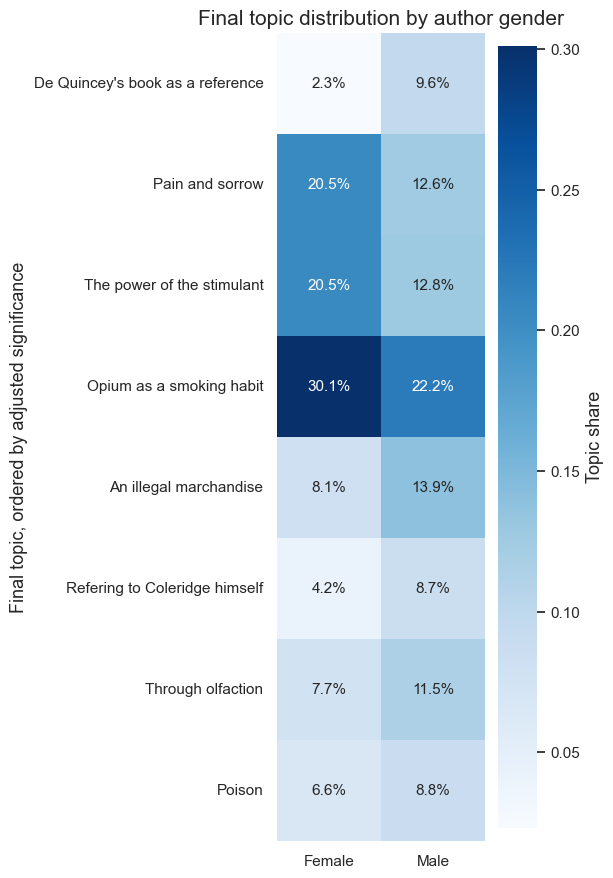

In [84]:
KNOWN_GENDER_GROUPS = ["Female", "Male"]
author_gender_df = df_final_topics.loc[
    df_final_topics["Author_Gender_Group"].isin(KNOWN_GENDER_GROUPS)
].copy()

author_gender_topic_distribution = topic_distribution(
    author_gender_df,
    group_cols="Author_Gender_Group",
    topic_col="bertopic_topic",
    label_col="topic_label",
    unit_col="sentence_id",
    include_outlier=False,
)
author_gender_top_topics = top_topics_by_group(author_gender_topic_distribution, "Author_Gender_Group", n_topics=12)
author_gender_global_test, author_gender_topic_tests, author_gender_pairwise_tests, author_gender_contingency = chi_square_topic_distribution_tests(
    author_gender_df,
    "Author_Gender_Group",
    topic_col="bertopic_topic",
    label_col="topic_label",
    unit_col="sentence_id",
    include_outlier=False,
)

display(author_gender_top_topics)
display_topic_distribution_tests(author_gender_global_test, author_gender_topic_tests, author_gender_pairwise_tests)
plot_topic_distribution_heatmap(
    author_gender_topic_distribution,
    "Author_Gender_Group",
    "Final topic distribution by author gender",
    top_n_topics=18,
    figsize=(6, 9),
    topic_significance=author_gender_topic_tests,
)

### b) Assigned gender

In [62]:
assigned_gender_counts = metadata_topic_counts(df_final_topics, "Assigned_Gender_Group")
assigned_gender_counts

,Assigned_Gender_Group,n_sentence_contexts,n_snippets,n_books,outlier_share
1,Male,1089,871,534,0.0
2,Unknown,383,311,244,0.0
0,Female,180,154,135,0.0
3,Unknown (Proper Noun),119,89,72,0.0


,Assigned_Gender_Group,bertopic_topic,topic_label,n_documents,group_total,topic_share
0,Male,1,Opium as a smoking habit,367,1089,0.337006
1,Male,6,The power of the stimulant,149,1089,0.136823
2,Male,9,An illegal marchandise,132,1089,0.121212
3,Male,16,Refering to Coleridge himself,116,1089,0.106520
4,Male,8,Pain and sorrow,99,1089,0.090909
5,Male,15,De Quincey's book as a reference,91,1089,0.083563
6,Male,13,Through olfaction,79,1089,0.072544
7,Male,19,Poison,56,1089,0.051423
8,Female,8,Pain and sorrow,76,180,0.422222
9,Female,9,An illegal marchandise,38,180,0.211111


,test,n_groups,n_topics,n_observations,chi2,dof,p_value,cramers_v
0,global_chi_square,2,8,1269,205.737092,7,6.989849e-41,0.402648


,group_a,group_b,n_observations,chi2,dof,p_value,cramers_v,p_adjusted_bh
0,Female,Male,1269,205.737092,7,6.989849e-41,0.402648,6.989849e-41


,bertopic_topic,topic_label,n_documents,chi2,dof,p_value,min_group_share,max_group_share,share_range,highest_share_group,lowest_share_group,p_adjusted_bh
2,8,Pain and sorrow,175,139.847959,1,2.873834e-32,0.090909,0.422222,0.331313,Female,Male,2.299067e-31
0,1,Opium as a smoking habit,376,59.656006,1,1.129740e-14,0.050000,0.337006,0.287006,Male,Female,4.518959e-14
6,16,Refering to Coleridge himself,117,17.626059,1,2.688787e-05,0.005556,0.106520,0.100964,Male,Female,7.170098e-05
3,9,An illegal marchandise,170,9.999391,1,1.565920e-03,0.121212,0.211111,0.089899,Female,Male,3.131840e-03
5,15,De Quincey's book as a reference,94,9.126837,1,2.518869e-03,0.016667,0.083563,0.066896,Male,Female,4.030190e-03
4,13,Through olfaction,100,3.557129,1,5.929021e-02,0.072544,0.116667,0.044123,Female,Male,7.905361e-02
1,6,The power of the stimulant,171,0.171080,1,6.791541e-01,0.122222,0.136823,0.014601,Male,Female,7.761761e-01
7,19,Poison,66,0.002511,1,9.600321e-01,0.051423,0.055556,0.004132,Female,Male,9.600321e-01


group_label,Female,Male
topic_label,,
Pain and sorrow,0.422222,0.090909
Opium as a smoking habit,0.050000,0.337006
Refering to Coleridge himself,0.005556,0.106520
An illegal marchandise,0.211111,0.121212
De Quincey's book as a reference,0.016667,0.083563
Through olfaction,0.116667,0.072544
The power of the stimulant,0.122222,0.136823
Poison,0.055556,0.051423


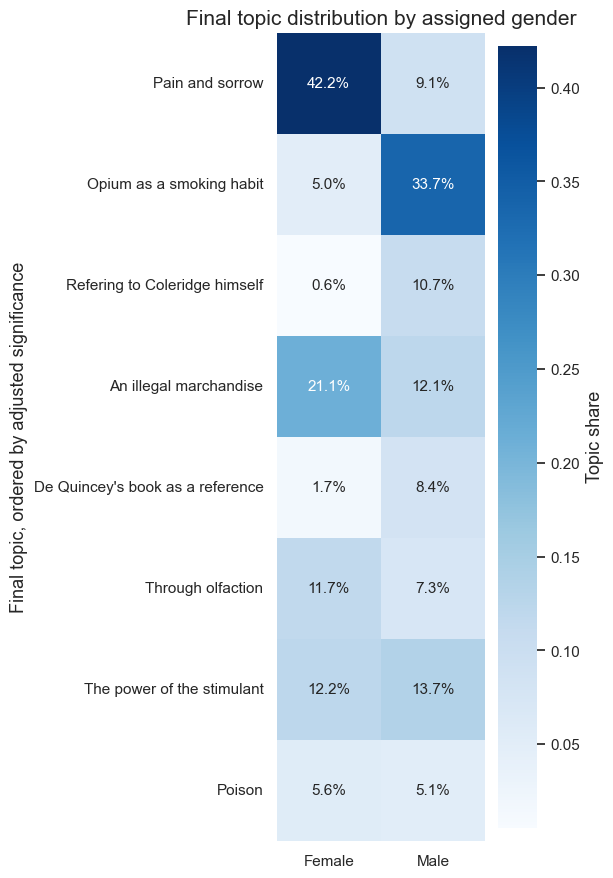

In [82]:
assigned_gender_df = df_final_topics.loc[
    df_final_topics["Assigned_Gender_Group"].isin(KNOWN_GENDER_GROUPS)
].copy()

assigned_gender_topic_distribution = topic_distribution(
    assigned_gender_df,
    group_cols="Assigned_Gender_Group",
    topic_col="bertopic_topic",
    label_col="topic_label",
    unit_col="sentence_id",
    include_outlier=False,
)
assigned_gender_top_topics = top_topics_by_group(assigned_gender_topic_distribution, "Assigned_Gender_Group", n_topics=12)
assigned_gender_global_test, assigned_gender_topic_tests, assigned_gender_pairwise_tests, assigned_gender_contingency = chi_square_topic_distribution_tests(
    assigned_gender_df,
    "Assigned_Gender_Group",
    topic_col="bertopic_topic",
    label_col="topic_label",
    unit_col="sentence_id",
    include_outlier=False,
)

display(assigned_gender_top_topics)
display_topic_distribution_tests(assigned_gender_global_test, assigned_gender_topic_tests, assigned_gender_pairwise_tests)
plot_topic_distribution_heatmap(
    assigned_gender_topic_distribution,
    "Assigned_Gender_Group",
    "Final topic distribution by assigned gender",
    top_n_topics=18,
    figsize=(6, 9),
    topic_significance=assigned_gender_topic_tests,
)

In [64]:
if EXPORT_RESULTS:
    author_gender_topic_distribution.to_csv(OUTPUT_DIR / "final_topics_by_author_gender.csv", index=False)
    assigned_gender_topic_distribution.to_csv(OUTPUT_DIR / "final_topics_by_assigned_gender.csv", index=False)
    author_gender_counts.to_csv(OUTPUT_DIR / "final_topic_author_gender_counts.csv", index=False)
    assigned_gender_counts.to_csv(OUTPUT_DIR / "final_topic_assigned_gender_counts.csv", index=False)
    author_gender_global_test.to_csv(OUTPUT_DIR / "final_topic_author_gender_global_test.csv", index=False)
    author_gender_pairwise_tests.to_csv(OUTPUT_DIR / "final_topic_author_gender_pairwise_tests.csv", index=False)
    author_gender_topic_tests.to_csv(OUTPUT_DIR / "final_topic_author_gender_topic_tests.csv", index=False)
    assigned_gender_global_test.to_csv(OUTPUT_DIR / "final_topic_assigned_gender_global_test.csv", index=False)
    assigned_gender_pairwise_tests.to_csv(OUTPUT_DIR / "final_topic_assigned_gender_pairwise_tests.csv", index=False)
    assigned_gender_topic_tests.to_csv(OUTPUT_DIR / "final_topic_assigned_gender_topic_tests.csv", index=False)

### C) Author's and Assigned gender

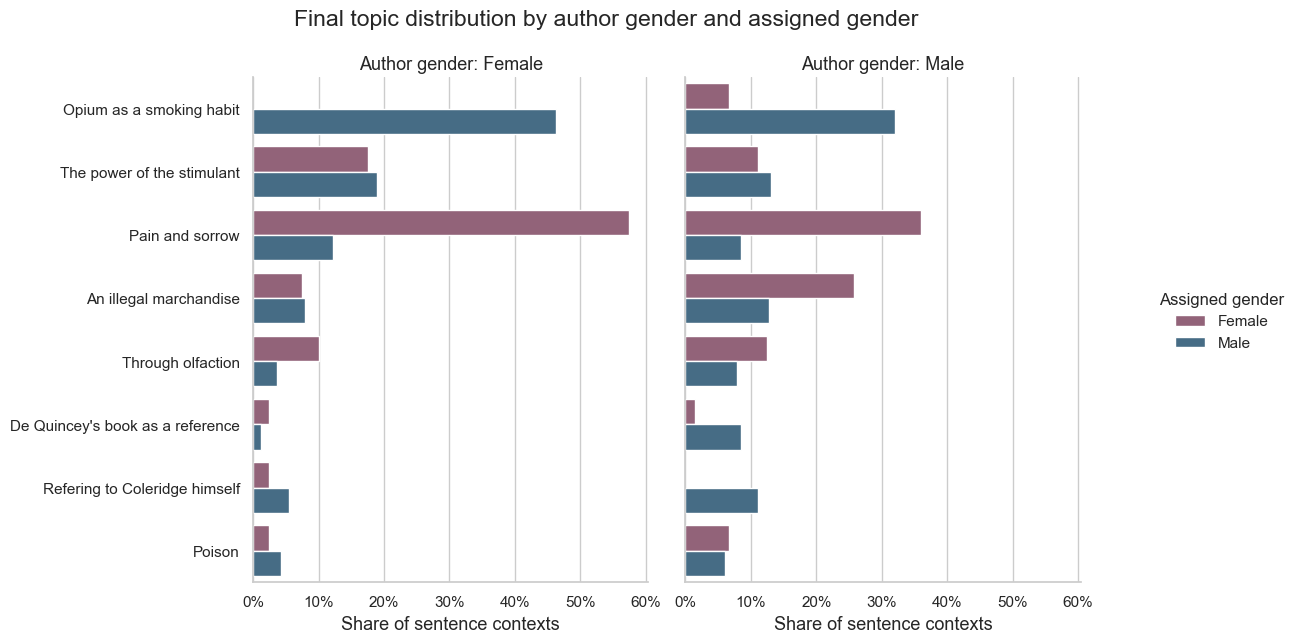

In [81]:
nested_gender_df = df_final_topics.loc[
    df_final_topics["Author_Gender_Group"].isin(KNOWN_GENDER_GROUPS)
    & df_final_topics["Assigned_Gender_Group"].isin(KNOWN_GENDER_GROUPS)
].copy()

nested_gender_topic_distribution = topic_distribution(
    nested_gender_df,
    group_cols=["Author_Gender_Group", "Assigned_Gender_Group"],
    topic_col="bertopic_topic",
    label_col="topic_label",
    unit_col="sentence_id",
    include_outlier=False,
)

nested_gender_plot_data = nested_gender_topic_distribution.copy()
nested_gender_plot_data["Author_Gender_Group"] = pd.Categorical(
    nested_gender_plot_data["Author_Gender_Group"],
    categories=KNOWN_GENDER_GROUPS,
    ordered=True,
)
nested_gender_plot_data["Assigned_Gender_Group"] = pd.Categorical(
    nested_gender_plot_data["Assigned_Gender_Group"],
    categories=KNOWN_GENDER_GROUPS,
    ordered=True,
)
nested_gender_plot_data["topic_label"] = pd.Categorical(
    nested_gender_plot_data["topic_label"],
    categories=list(SELECTED_TOPIC_LABELS.values()),
    ordered=True,
)
nested_gender_plot_data = nested_gender_plot_data.sort_values(
    ["Author_Gender_Group", "Assigned_Gender_Group", "topic_label"]
)

nested_gender_plot = sns.catplot(
    data=nested_gender_plot_data,
    kind="bar",
    x="topic_share",
    y="topic_label",
    hue="Assigned_Gender_Group",
    col="Author_Gender_Group",
    col_order=KNOWN_GENDER_GROUPS,
    hue_order=KNOWN_GENDER_GROUPS,
    height=6.2,
    aspect=0.95,
    palette={"Female": "#9a5b78", "Male": "#3b6f8f"},
    sharex=True,
    legend_out=True,
)
nested_gender_plot.set_axis_labels("Share of sentence contexts", "")
nested_gender_plot.set_titles("Author gender: {col_name}")
nested_gender_plot.fig.suptitle(
    "Final topic distribution by author gender and assigned gender",
    y=1.04,
)
for ax in nested_gender_plot.axes.flat:
    ax.xaxis.set_major_formatter(StrMethodFormatter("{x:.0%}"))
    ax.tick_params(axis="y", labelsize=11)
    ax.tick_params(axis="x", labelsize=11)
    ax.set_xlim(left=0)
if nested_gender_plot._legend is not None:
    nested_gender_plot._legend.set_title("Assigned gender")
plt.show()


## 5) Topic distribution by Nationality

`LoCC` is kept as the grouping field. The heatmap uses the largest LoCC groups for readability, while the exported table keeps all LoCC values.

In [65]:
locc_focus_values = ["PR", "PS"]
locc_focus_df = df_final_topics.loc[df_final_topics["LoCC_Display"].isin(locc_focus_values)].copy()
locc_counts = metadata_topic_counts(locc_focus_df, "LoCC_Display")
locc_counts

,LoCC_Display,n_sentence_contexts,n_snippets,n_books,outlier_share
0,PR,1011,807,433,0.0
1,PS,688,565,357,0.0


,LoCC_Display,bertopic_topic,topic_label,n_documents,group_total,topic_share
0,PS,1,Opium as a smoking habit,153,688,0.222384
1,PS,9,An illegal marchandise,131,688,0.190407
2,PS,6,The power of the stimulant,99,688,0.143895
3,PS,8,Pain and sorrow,97,688,0.140988
4,PS,13,Through olfaction,96,688,0.139535
5,PS,19,Poison,78,688,0.113372
6,PS,15,De Quincey's book as a reference,28,688,0.040698
7,PS,16,Refering to Coleridge himself,6,688,0.008721
8,PR,1,Opium as a smoking habit,246,1011,0.243323
9,PR,15,De Quincey's book as a reference,138,1011,0.136499


,test,n_groups,n_topics,n_observations,chi2,dof,p_value,cramers_v
0,global_chi_square,2,8,1699,187.953212,7,4.064757e-37,0.332605


,group_a,group_b,n_observations,chi2,dof,p_value,cramers_v,p_adjusted_bh
0,PR,PS,1699,187.953212,7,4.064757e-37,0.332605,4.064757e-37


,bertopic_topic,topic_label,n_documents,chi2,dof,p_value,min_group_share,max_group_share,share_range,highest_share_group,lowest_share_group,p_adjusted_bh
6,16,Refering to Coleridge himself,144,84.529345,1,3.785544e-20,0.008721,0.136499,0.127778,PR,PS,3.028435e-19
3,9,An illegal marchandise,213,43.612203,1,4.003349e-11,0.081108,0.190407,0.109299,PS,PR,1.601340e-10
5,15,De Quincey's book as a reference,166,41.541015,1,1.154237e-10,0.040698,0.136499,0.095801,PR,PS,3.077966e-10
7,19,Poison,131,20.524071,1,5.888606e-06,0.052423,0.113372,0.060949,PS,PR,1.177721e-05
4,13,Through olfaction,184,11.144149,1,8.429715e-04,0.087043,0.139535,0.052492,PS,PR,1.348754e-03
0,1,Opium as a smoking habit,399,0.885851,1,3.466040e-01,0.222384,0.243323,0.020940,PR,PS,4.621387e-01
1,6,The power of the stimulant,233,0.355168,1,5.512020e-01,0.132542,0.143895,0.011353,PS,PR,5.855500e-01
2,8,Pain and sorrow,229,0.297348,1,5.855500e-01,0.130564,0.140988,0.010425,PS,PR,5.855500e-01


group_label,PR,PS
topic_label,,
Refering to Coleridge himself,0.136499,0.008721
An illegal marchandise,0.081108,0.190407
De Quincey's book as a reference,0.136499,0.040698
Poison,0.052423,0.113372
Through olfaction,0.087043,0.139535
Opium as a smoking habit,0.243323,0.222384
The power of the stimulant,0.132542,0.143895
Pain and sorrow,0.130564,0.140988


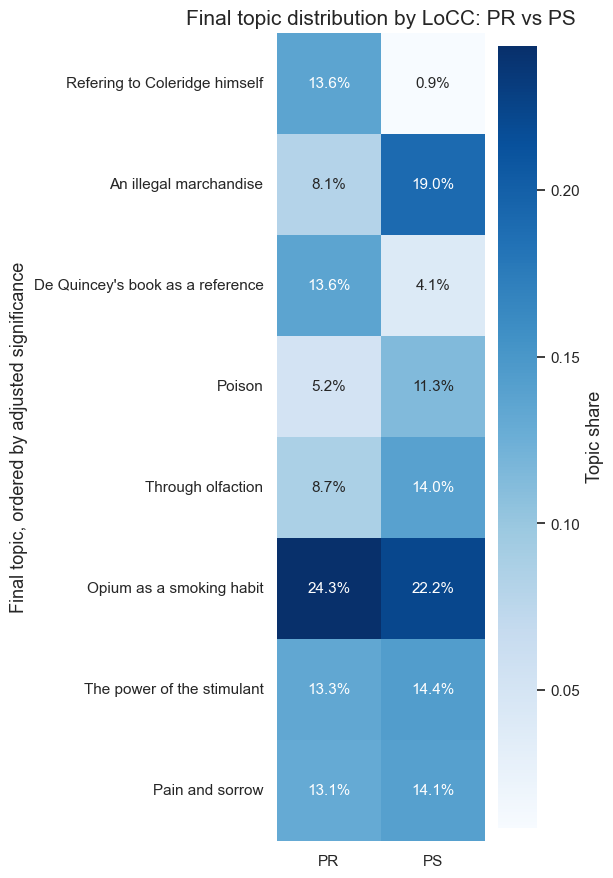

In [80]:
locc_topic_distribution = topic_distribution(
    locc_focus_df,
    group_cols="LoCC_Display",
    topic_col="bertopic_topic",
    label_col="topic_label",
    unit_col="sentence_id",
    include_outlier=False,
)
locc_top_topics = top_topics_by_group(locc_topic_distribution, "LoCC_Display", n_topics=10)
locc_test_df = locc_focus_df.copy()
locc_global_test, locc_topic_tests, locc_pairwise_tests, locc_contingency = chi_square_topic_distribution_tests(
    locc_test_df,
    "LoCC_Display",
    topic_col="bertopic_topic",
    label_col="topic_label",
    unit_col="sentence_id",
    include_outlier=False,
)

display(locc_top_topics.head(40))
display_topic_distribution_tests(locc_global_test, locc_topic_tests, locc_pairwise_tests)
plot_topic_distribution_heatmap(
    locc_topic_distribution,
    "LoCC_Display",
    "Final topic distribution by LoCC: PR vs PS",
    top_n_topics=20,
    figsize=(6, 9),
    topic_significance=locc_topic_tests,
)

In [67]:
if EXPORT_RESULTS:
    locc_topic_distribution.to_csv(OUTPUT_DIR / "final_topics_by_locc.csv", index=False)
    locc_counts.to_csv(OUTPUT_DIR / "final_topic_locc_counts.csv", index=False)
    locc_global_test.to_csv(OUTPUT_DIR / "final_topic_locc_global_test.csv", index=False)
    locc_pairwise_tests.to_csv(OUTPUT_DIR / "final_topic_locc_pairwise_tests.csv", index=False)
    locc_topic_tests.to_csv(OUTPUT_DIR / "final_topic_locc_topic_tests.csv", index=False)

## 6) Topic distribution by Period

The period comparison keeps the four 20-year bins created earlier. Use `PERIOD_TOPIC_IDS_TO_PLOT` to choose specific final BERTopic topic numbers for the temporal line plot. Leave it empty to show the most statistically distinctive temporal topics.

In [68]:
PERIOD_TOPIC_IDS_TO_PLOT = []  # Example: [0, 4, 15]

period_counts = metadata_topic_counts(df_final_topics, "Period")
period_counts

,Period,n_sentence_contexts,n_snippets,n_books,outlier_share
2,1912-1930,751,585,301,0.0
1,1881-1911,746,622,388,0.0
0,1850-1880,274,218,129,0.0


,Period,bertopic_topic,topic_label,n_documents,group_total,topic_share
0,1912-1930,1,Opium as a smoking habit,180,751,0.239680
1,1912-1930,15,De Quincey's book as a reference,104,751,0.138482
2,1912-1930,13,Through olfaction,100,751,0.133156
3,1912-1930,8,Pain and sorrow,98,751,0.130493
4,1912-1930,9,An illegal marchandise,91,751,0.121172
5,1912-1930,6,The power of the stimulant,85,751,0.113182
6,1912-1930,16,Refering to Coleridge himself,51,751,0.067909
7,1912-1930,19,Poison,42,751,0.055925
8,1881-1911,1,Opium as a smoking habit,173,746,0.231903
9,1881-1911,6,The power of the stimulant,117,746,0.156836


,test,n_groups,n_topics,n_observations,chi2,dof,p_value,cramers_v
0,global_chi_square,3,8,1771,70.14969,14,1.813266e-09,0.140731


,group_a,group_b,n_observations,chi2,dof,p_value,cramers_v,p_adjusted_bh
1,1850-1880,1912-1930,1025,44.191582,7,1.962100e-07,0.207638,5.886301e-07
2,1881-1911,1912-1930,1497,35.980511,7,7.310930e-06,0.155033,1.096639e-05
0,1850-1880,1881-1911,1020,17.959370,7,1.215467e-02,0.132692,1.215467e-02


,bertopic_topic,topic_label,n_documents,chi2,dof,p_value,min_group_share,max_group_share,share_range,highest_share_group,lowest_share_group,p_adjusted_bh
6,16,Refering to Coleridge himself,154,24.837459,2,0.000004,0.067909,0.164234,0.096324,1850-1880,1912-1930,0.000026
5,15,De Quincey's book as a reference,174,23.859278,2,0.000007,0.065693,0.138482,0.072789,1912-1930,1850-1880,0.000026
4,13,Through olfaction,189,11.386439,2,0.003369,0.065693,0.133156,0.067462,1912-1930,1850-1880,0.008983
7,19,Poison,138,8.824133,2,0.012130,0.055925,0.095174,0.039249,1881-1911,1912-1930,0.024260
1,6,The power of the stimulant,243,6.447069,2,0.039814,0.113182,0.156836,0.043654,1881-1911,1912-1930,0.063703
0,1,Opium as a smoking habit,408,1.734715,2,0.420060,0.200730,0.239680,0.038950,1912-1930,1850-1880,0.560080
3,9,An illegal marchandise,227,0.677475,2,0.712669,0.121172,0.135389,0.014217,1881-1911,1912-1930,0.814479
2,8,Pain and sorrow,238,0.185877,2,0.911250,0.130493,0.138070,0.007577,1881-1911,1912-1930,0.911250


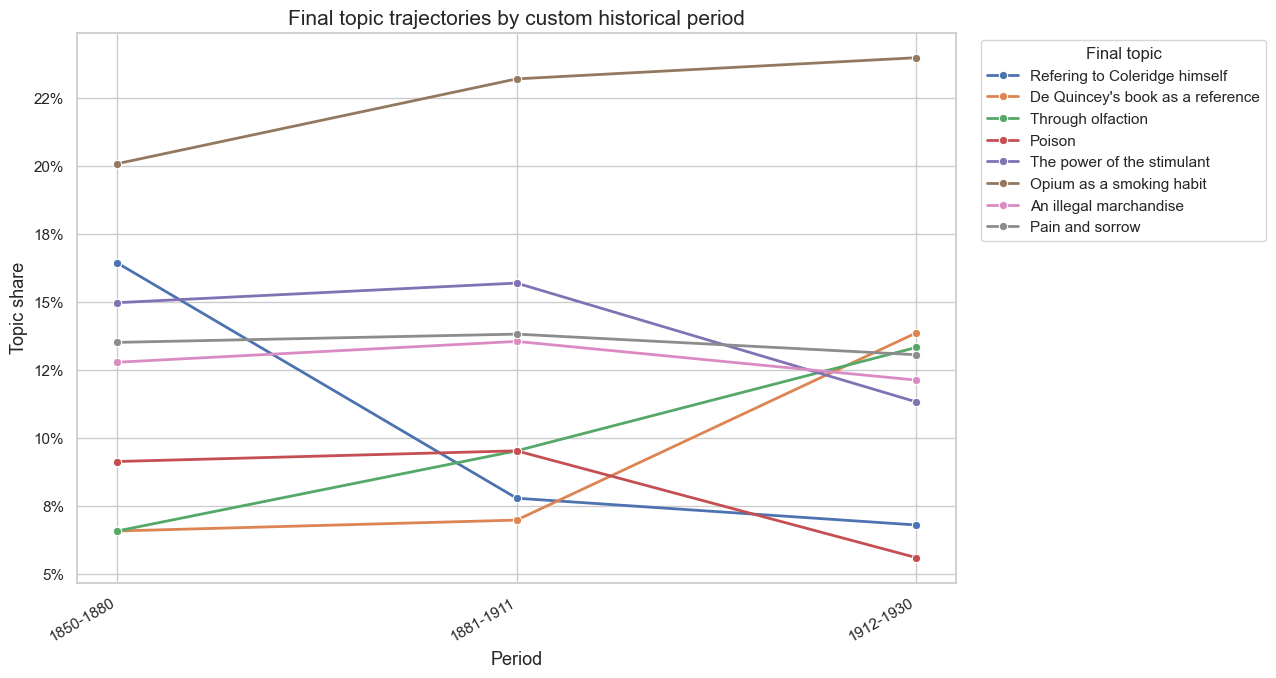

In [69]:
period_topic_distribution = topic_distribution(
    df_final_topics,
    group_cols="Period",
    topic_col="bertopic_topic",
    label_col="topic_label",
    unit_col="sentence_id",
    include_outlier=False,
)
period_top_topics = top_topics_by_group(period_topic_distribution, "Period", n_topics=12)
period_global_test, period_topic_tests, period_pairwise_tests, period_contingency = chi_square_topic_distribution_tests(
    df_final_topics,
    "Period",
    topic_col="bertopic_topic",
    label_col="topic_label",
    unit_col="sentence_id",
    include_outlier=False,
)

display(period_top_topics)
display_topic_distribution_tests(period_global_test, period_topic_tests, period_pairwise_tests)
period_line_plot_data = plot_topic_distribution_lines(
    period_topic_distribution,
    period_col="Period",
    selected_topic_ids=PERIOD_TOPIC_IDS_TO_PLOT,
    title="Final topic trajectories by custom historical period",
    top_n_topics=8,
    figsize=(13, 7),
    topic_significance=period_topic_tests,
)

In [70]:
if EXPORT_RESULTS:
    period_topic_distribution.to_csv(OUTPUT_DIR / "final_topics_by_period.csv", index=False)
    period_counts.to_csv(OUTPUT_DIR / "final_topic_period_counts.csv", index=False)
    period_global_test.to_csv(OUTPUT_DIR / "final_topic_period_global_test.csv", index=False)
    period_pairwise_tests.to_csv(OUTPUT_DIR / "final_topic_period_pairwise_tests.csv", index=False)
    period_topic_tests.to_csv(OUTPUT_DIR / "final_topic_period_topic_tests.csv", index=False)

## 7) Combining Gender, Nationality and Period for Topic Distribution

### a) Sanity check: snippet distribution

In [71]:
combo_author_counts = (
    author_gender_df
    .groupby(["Author_Gender_Group", "LoCC_Display", "Period"])
    .agg(
        n_sentence_contexts=("sentence_id", "nunique"),
        n_snippets=("snippet_id", "nunique"),
        n_books=("Book_ID", "nunique"),
        outlier_share=("bertopic_topic", lambda s: (s.astype(int) == -1).mean()),
    )
    .reset_index()
    .sort_values("n_sentence_contexts", ascending=False)
)
combo_author_counts.head(30)

,Author_Gender_Group,LoCC_Display,Period,n_sentence_contexts,n_snippets,n_books,outlier_share
19,Male,PR,1881-1911,322,261,160,0.0
20,Male,PR,1912-1930,260,212,98,0.0
26,Male,PS,1912-1930,235,180,95,0.0
25,Male,PS,1881-1911,233,190,120,0.0
18,Male,PR,1850-1880,126,90,47,0.0
2,Female,PR,1881-1911,85,79,49,0.0
5,Female,PS,1881-1911,53,49,37,0.0
24,Male,PS,1850-1880,44,37,29,0.0
6,Female,PS,1912-1930,34,31,27,0.0
1,Female,PR,1850-1880,31,29,14,0.0


In [72]:
combo_assigned_counts = (
    assigned_gender_df
    .groupby(["Assigned_Gender_Group", "LoCC_Display", "Period"])
    .agg(
        n_sentence_contexts=("sentence_id", "nunique"),
        n_snippets=("snippet_id", "nunique"),
        n_books=("Book_ID", "nunique"),
        outlier_share=("bertopic_topic", lambda s: (s.astype(int) == -1).mean()),
    )
    .reset_index()
    .sort_values("n_sentence_contexts", ascending=False)
)
combo_assigned_counts.head(30)

,Assigned_Gender_Group,LoCC_Display,Period,n_sentence_contexts,n_snippets,n_books,outlier_share
18,Male,PR,1881-1911,278,230,146,0.0
19,Male,PR,1912-1930,239,188,100,0.0
26,Male,PS,1912-1930,214,161,97,0.0
25,Male,PS,1881-1911,158,138,95,0.0
17,Male,PR,1850-1880,116,86,47,0.0
8,Female,PS,1881-1911,45,33,27,0.0
3,Female,PR,1881-1911,43,40,36,0.0
24,Male,PS,1850-1880,43,39,32,0.0
9,Female,PS,1912-1930,31,27,25,0.0
4,Female,PR,1912-1930,30,29,24,0.0


### b) Author gender + LoCC + Period

In [73]:
combo_author_topic_distribution = topic_distribution(
    author_gender_df,
    group_cols=["Author_Gender_Group", "LoCC_Display", "Period"],
    topic_col="bertopic_topic",
    label_col="topic_label",
    unit_col="sentence_id",
    include_outlier=False,
)
combo_author_top_topics = top_topics_by_group(
    combo_author_topic_distribution,
    ["Author_Gender_Group", "LoCC_Display", "Period"],
    n_topics=5,
)
combo_author_plot_mask = (
    author_gender_df["LoCC_Display"].isin(["PR", "PS"])
)
combo_author_global_test, combo_author_topic_tests, combo_author_pairwise_tests, combo_author_contingency = chi_square_topic_distribution_tests(
    author_gender_df.loc[combo_author_plot_mask],
    ["Author_Gender_Group", "LoCC_Display", "Period"],
    topic_col="bertopic_topic",
    label_col="topic_label",
    unit_col="sentence_id",
    include_outlier=False,
    min_group_total=30,
)

display(combo_author_top_topics.head(60))
display_topic_distribution_tests(combo_author_global_test, combo_author_topic_tests, combo_author_pairwise_tests)

,Author_Gender_Group,LoCC_Display,Period,bertopic_topic,topic_label,n_documents,group_total,topic_share
0,Male,PS,1912-1930,1,Opium as a smoking habit,62,235,0.263830
1,Male,PS,1912-1930,9,An illegal marchandise,52,235,0.221277
2,Male,PS,1912-1930,6,The power of the stimulant,31,235,0.131915
3,Male,PS,1912-1930,8,Pain and sorrow,30,235,0.127660
4,Male,PS,1912-1930,13,Through olfaction,30,235,0.127660
5,Male,PS,1881-1911,1,Opium as a smoking habit,44,233,0.188841
6,Male,PS,1881-1911,19,Poison,44,233,0.188841
7,Male,PS,1881-1911,9,An illegal marchandise,41,233,0.175966
8,Male,PS,1881-1911,13,Through olfaction,32,233,0.137339
9,Male,PS,1881-1911,8,Pain and sorrow,31,233,0.133047


,test,n_groups,n_topics,n_observations,chi2,dof,p_value,cramers_v
0,global_chi_square,10,8,1423,359.546534,63,4.047125e-43,0.189988


,group_a,group_b,n_observations,chi2,dof,p_value,cramers_v,p_adjusted_bh
33,Male | PR | 1850-1880,Male | PS | 1881-1911,359,89.267049,7,1.749582e-16,0.498653,7.873117e-15
34,Male | PR | 1850-1880,Male | PS | 1912-1930,361,78.086637,7,3.380360e-14,0.465088,7.605809e-13
37,Male | PR | 1881-1911,Male | PS | 1881-1911,555,70.471594,7,1.186264e-12,0.356337,1.779397e-11
40,Male | PR | 1912-1930,Male | PS | 1881-1911,493,63.140299,7,3.552272e-11,0.357874,3.996306e-10
41,Male | PR | 1912-1930,Male | PS | 1912-1930,495,54.486157,7,1.884589e-09,0.331773,1.696130e-08
38,Male | PR | 1881-1911,Male | PS | 1912-1930,557,53.699305,7,2.696983e-09,0.310497,2.022737e-08
31,Male | PR | 1850-1880,Male | PR | 1912-1930,386,48.051005,7,3.479788e-08,0.352824,2.237006e-07
15,Female | PR | 1881-1911,Male | PS | 1881-1911,318,45.758164,7,9.742131e-08,0.379333,5.479949e-07
14,Female | PR | 1881-1911,Male | PS | 1850-1880,129,38.665262,7,2.263859e-06,0.547477,1.131930e-05
11,Female | PR | 1881-1911,Male | PR | 1850-1880,211,35.096435,7,1.072721e-05,0.407840,4.458602e-05


,bertopic_topic,topic_label,n_documents,chi2,dof,p_value,min_group_share,max_group_share,share_range,highest_share_group,lowest_share_group,p_adjusted_bh
6,16,Refering to Coleridge himself,114,145.165957,9,8.831714e-27,0.000000,0.309524,0.309524,Male | PR | 1850-1880,Female | PS | 1881-1911,7.065371e-26
3,9,An illegal marchandise,182,51.761946,9,5.013838e-08,0.032258,0.250000,0.217742,Male | PS | 1850-1880,Female | PR | 1850-1880,2.005535e-07
7,19,Poison,115,50.019735,9,1.068073e-07,0.029412,0.188841,0.159429,Male | PS | 1881-1911,Female | PS | 1912-1930,2.637988e-07
5,15,De Quincey's book as a reference,119,49.532030,9,1.318994e-07,0.000000,0.161538,0.161538,Male | PR | 1912-1930,Female | PR | 1881-1911,2.637988e-07
1,6,The power of the stimulant,199,31.942668,9,2.037237e-04,0.045455,0.352941,0.307487,Female | PS | 1912-1930,Male | PS | 1850-1880,3.259580e-04
0,1,Opium as a smoking habit,345,27.634960,9,1.097420e-03,0.136364,0.516129,0.379765,Female | PR | 1850-1880,Male | PS | 1850-1880,1.319754e-03
4,13,Through olfaction,160,27.501960,9,1.154784e-03,0.032258,0.181818,0.149560,Male | PS | 1850-1880,Female | PR | 1850-1880,1.319754e-03
2,8,Pain and sorrow,189,19.235848,9,2.326056e-02,0.032258,0.270588,0.238330,Female | PR | 1881-1911,Female | PR | 1850-1880,2.326056e-02


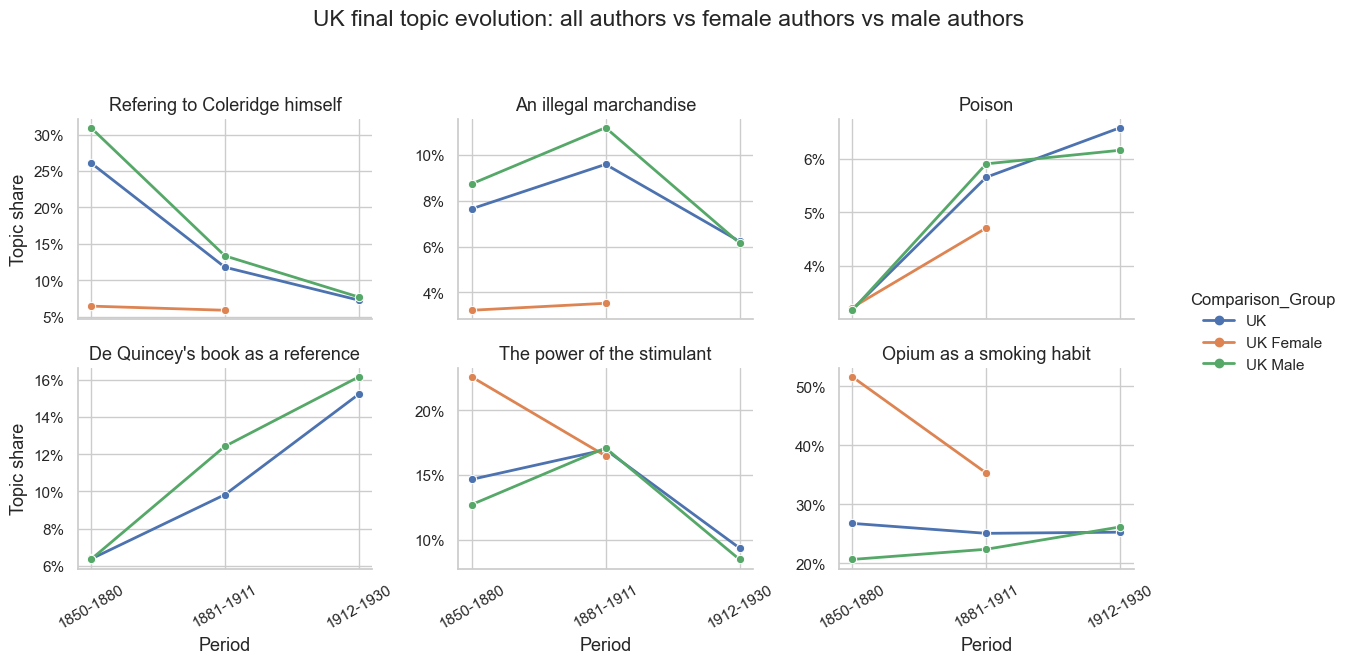

In [74]:
combo_author_uk_line_plot_data = plot_uk_gender_topic_evolution(
    author_gender_df,
    gender_col="Author_Gender_Group",
    title="UK final topic evolution: all authors vs female authors vs male authors",
    top_n_topics=6,
    min_group_total=30,
    topic_significance=combo_author_topic_tests,
)

### c) Assigned gender + LoCC + Period

In [75]:
combo_assigned_topic_distribution = topic_distribution(
    assigned_gender_df,
    group_cols=["Assigned_Gender_Group", "LoCC_Display", "Period"],
    topic_col="bertopic_topic",
    label_col="topic_label",
    unit_col="sentence_id",
    include_outlier=False,
)
combo_assigned_top_topics = top_topics_by_group(
    combo_assigned_topic_distribution,
    ["Assigned_Gender_Group", "LoCC_Display", "Period"],
    n_topics=5,
)
combo_assigned_plot_mask = (
    assigned_gender_df["LoCC_Display"].isin(["PR", "PS"])
)
combo_assigned_global_test, combo_assigned_topic_tests, combo_assigned_pairwise_tests, combo_assigned_contingency = chi_square_topic_distribution_tests(
    assigned_gender_df.loc[combo_assigned_plot_mask],
    ["Assigned_Gender_Group", "LoCC_Display", "Period"],
    topic_col="bertopic_topic",
    label_col="topic_label",
    unit_col="sentence_id",
    include_outlier=False,
    min_group_total=30,
)

display(combo_assigned_top_topics.head(60))
display_topic_distribution_tests(combo_assigned_global_test, combo_assigned_topic_tests, combo_assigned_pairwise_tests)

,Assigned_Gender_Group,LoCC_Display,Period,bertopic_topic,topic_label,n_documents,group_total,topic_share
0,Male,PZ; PS,1881-1911,9,An illegal marchandise,3,4,0.750000
1,Male,PZ; PS,1881-1911,1,Opium as a smoking habit,1,4,0.250000
2,Male,PS,1912-1930,1,Opium as a smoking habit,77,214,0.359813
3,Male,PS,1912-1930,9,An illegal marchandise,49,214,0.228972
4,Male,PS,1912-1930,6,The power of the stimulant,28,214,0.130841
5,Male,PS,1912-1930,13,Through olfaction,24,214,0.112150
6,Male,PS,1912-1930,8,Pain and sorrow,16,214,0.074766
7,Male,PS,1881-1911,1,Opium as a smoking habit,54,158,0.341772
8,Male,PS,1881-1911,6,The power of the stimulant,26,158,0.164557
9,Male,PS,1881-1911,9,An illegal marchandise,23,158,0.145570


,test,n_groups,n_topics,n_observations,chi2,dof,p_value,cramers_v
0,global_chi_square,10,8,1197,432.251948,63,1.755268e-56,0.227129


,group_a,group_b,n_observations,chi2,dof,p_value,cramers_v,p_adjusted_bh
4,Female | PR | 1881-1911,Male | PR | 1881-1911,321,79.051598,7,2.149889e-14,0.496253,9.674500e-13
20,Female | PS | 1881-1911,Male | PR | 1912-1930,284,71.713156,7,6.652758e-13,0.502505,1.427929e-11
41,Male | PR | 1912-1930,Male | PS | 1912-1930,453,70.704392,7,1.064408e-12,0.395070,1.427929e-11
5,Female | PR | 1881-1911,Male | PR | 1912-1930,282,70.240509,7,1.320984e-12,0.499079,1.427929e-11
8,Female | PR | 1881-1911,Male | PS | 1912-1930,257,69.846798,7,1.586588e-12,0.521323,1.427929e-11
34,Male | PR | 1850-1880,Male | PS | 1912-1930,330,69.148938,7,2.194914e-12,0.457758,1.646186e-11
18,Female | PS | 1881-1911,Male | PR | 1850-1880,161,68.216988,7,3.384464e-12,0.650929,2.175727e-11
3,Female | PR | 1881-1911,Male | PR | 1850-1880,159,66.439504,7,7.720803e-12,0.646420,4.342952e-11
19,Female | PS | 1881-1911,Male | PR | 1881-1911,323,66.147334,7,8.840310e-12,0.452538,4.420155e-11
40,Male | PR | 1912-1930,Male | PS | 1881-1911,397,58.266950,7,3.345376e-10,0.383103,1.505419e-09


,bertopic_topic,topic_label,n_documents,chi2,dof,p_value,min_group_share,max_group_share,share_range,highest_share_group,lowest_share_group,p_adjusted_bh
2,8,Pain and sorrow,159,150.068401,9,8.536520e-28,0.068966,0.558140,0.489174,Female | PR | 1881-1911,Male | PR | 1850-1880,6.829216e-27
6,16,Refering to Coleridge himself,108,105.291306,9,1.332546e-18,0.000000,0.267241,0.267241,Male | PR | 1850-1880,Female | PR | 1912-1930,5.330183e-18
3,9,An illegal marchandise,153,71.277805,9,8.547279e-12,0.043103,0.333333,0.290230,Female | PS | 1881-1911,Male | PR | 1850-1880,2.279274e-11
5,15,De Quincey's book as a reference,89,52.675412,9,3.367688e-08,0.000000,0.171548,0.171548,Male | PR | 1912-1930,Female | PR | 1881-1911,6.735377e-08
0,1,Opium as a smoking habit,367,51.697224,9,5.157035e-08,0.000000,0.359813,0.359813,Male | PS | 1912-1930,Female | PS | 1912-1930,8.251257e-08
7,19,Poison,62,22.453156,9,7.548549e-03,0.000000,0.116279,0.116279,Male | PS | 1850-1880,Female | PR | 1912-1930,1.006473e-02
1,6,The power of the stimulant,160,21.509164,9,1.057178e-02,0.033333,0.193548,0.160215,Female | PS | 1912-1930,Female | PR | 1912-1930,1.099250e-02
4,13,Through olfaction,99,21.398847,9,1.099250e-02,0.034483,0.225806,0.191324,Female | PS | 1912-1930,Male | PR | 1850-1880,1.099250e-02


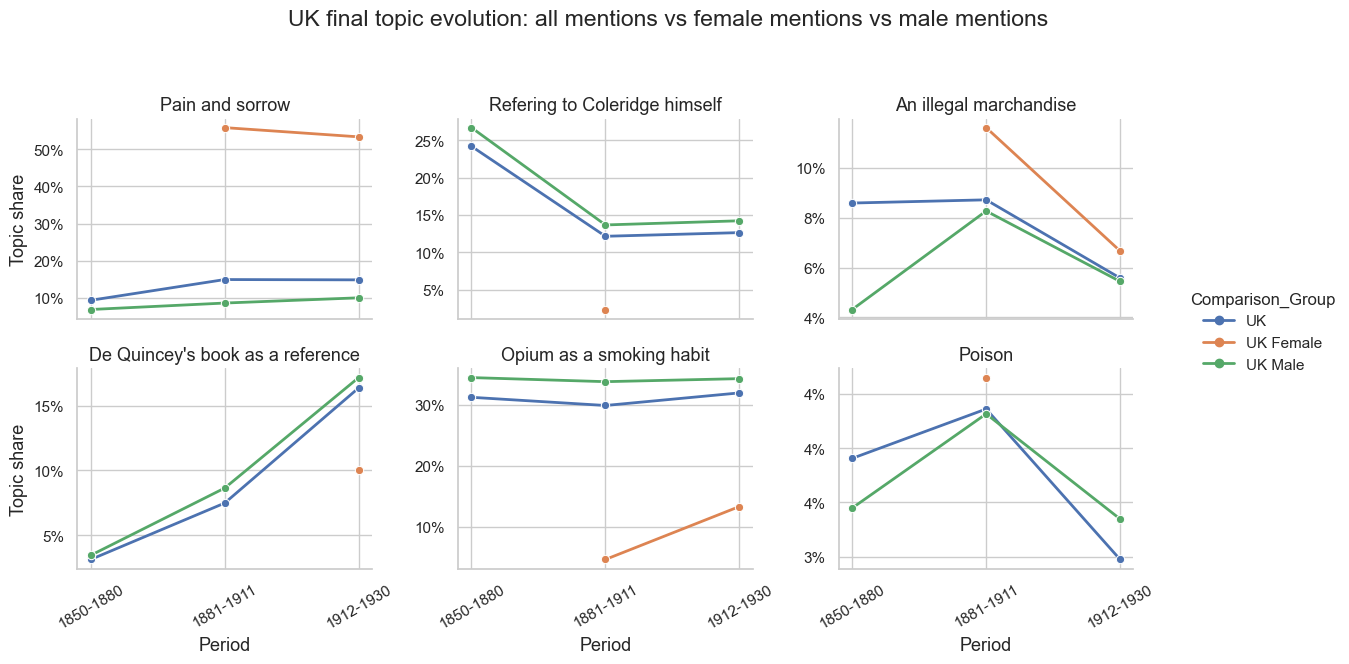

In [76]:
combo_assigned_uk_line_plot_data = plot_uk_gender_topic_evolution(
    assigned_gender_df,
    gender_col="Assigned_Gender_Group",
    title="UK final topic evolution: all mentions vs female mentions vs male mentions",
    top_n_topics=6,
    min_group_total=30,
    topic_significance=combo_assigned_topic_tests,
)

In [77]:
if EXPORT_RESULTS:
    combo_author_counts.to_csv(OUTPUT_DIR / "final_topic_author_gender_locc_period_counts.csv", index=False)
    combo_assigned_counts.to_csv(OUTPUT_DIR / "final_topic_assigned_gender_locc_period_counts.csv", index=False)
    combo_author_topic_distribution.to_csv(OUTPUT_DIR / "final_topics_by_author_gender_locc_period.csv", index=False)
    combo_assigned_topic_distribution.to_csv(OUTPUT_DIR / "final_topics_by_assigned_gender_locc_period.csv", index=False)
    combo_author_global_test.to_csv(OUTPUT_DIR / "final_topic_author_gender_locc_period_global_test.csv", index=False)
    combo_author_pairwise_tests.to_csv(OUTPUT_DIR / "final_topic_author_gender_locc_period_pairwise_tests.csv", index=False)
    combo_author_topic_tests.to_csv(OUTPUT_DIR / "final_topic_author_gender_locc_period_topic_tests.csv", index=False)
    combo_assigned_global_test.to_csv(OUTPUT_DIR / "final_topic_assigned_gender_locc_period_global_test.csv", index=False)
    combo_assigned_pairwise_tests.to_csv(OUTPUT_DIR / "final_topic_assigned_gender_locc_period_pairwise_tests.csv", index=False)
    combo_assigned_topic_tests.to_csv(OUTPUT_DIR / "final_topic_assigned_gender_locc_period_topic_tests.csv", index=False)